<a href="https://colab.research.google.com/github/xd2285-cloud/FRED-final-project/blob/main/FRED_inflation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting changes in U.S. inflation expectations using financial market indicators.**

Target:

The main variable is T10YIE, the 10-year breakeven inflation rate. It represents market expectations for average inflation over the next 10 years. If T10YIE rises, markets are pricing in higher expected inflation.


Features:

T10YIE and T5YIE: current long-term and medium-term inflation expectations.
T5YIFR: forward inflation expectation, useful for whether long-run expectations are becoming unanchored.
Treasury yields: nominal rates reflect growth, inflation, and Fed policy expectations.
TIPS real yields: help separate real-rate changes from inflation-expectation changes.
VIX: risk sentiment. In stress periods, inflation expectations may fall because markets expect weaker demand.
Oil and gas: energy shocks can push inflation expectations higher.
FX rates: dollar moves affect import prices and commodity pricing.


# 1. Load data

In [1]:
# Install if needed
!pip install pandas_datareader


In [7]:
import pandas as pd
import numpy as np
from pandas_datareader import data as web
import matplotlib.pyplot as plt
import time
import requests

In [3]:
api_key='f1f7688ec1ed7063583c49c1e593898d'


In [4]:
series_ids = {
    't10yie': 'T10YIE',
    't5yie': 'T5YIE',
    't5yifr': 'T5YIFR',

    'dgs2': 'DGS2',
    'dgs5': 'DGS5',
    'dgs10': 'DGS10',
    'dgs30': 'DGS30',

    'dfii5': 'DFII5',
    'dfii10': 'DFII10',

    'vix': 'VIXCLS',

    'wti_oil': 'DCOILWTICO',
    'brent_oil': 'DCOILBRENTEU',
    'natural_gas': 'DHHNGSP',


    'eur_usd': 'DEXUSEU',
    'yen_usd': 'DEXJPUS',
    'pound_usd': 'DEXUSUK',
    'canada_usd': 'DEXCAUS'
}

start_date = '2000-01-01'
end_date = '2024-12-31'


In [5]:
def load_fred_api(series_id, name, start_date, end_date, api_key, retries=3):
    url = 'https://api.stlouisfed.org/fred/series/observations'

    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start_date,
        'observation_end': end_date
    }

    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()

            data = response.json()

            observations = data['observations']

            temp = pd.DataFrame(observations)

            temp['date'] = pd.to_datetime(temp['date'])
            temp[name] = pd.to_numeric(temp['value'].replace('.', np.nan), errors='coerce')

            temp = temp[['date', name]]
            temp = temp.set_index('date')

            return temp

        except Exception as e:
            print(f'Attempt {attempt + 1} failed for {name}: {series_id}')
            print(e)
            time.sleep(3)

    print(f'Could not load {name}: {series_id}')
    return None


In [8]:
fred_data = {}

for name, series_id in series_ids.items():
    temp = load_fred_api(
        series_id=series_id,
        name=name,
        start_date=start_date,
        end_date=end_date,
        api_key=api_key
    )

    if temp is not None:
        fred_data[name] = temp
        print(f'Loaded {name}: {series_id}, shape = {temp.shape}')

    time.sleep(1)

df_raw = pd.concat(fred_data.values(), axis=1)

df_raw.head()


Loaded t10yie: T10YIE, shape = (5739, 1)
Loaded t5yie: T5YIE, shape = (5739, 1)
Loaded t5yifr: T5YIFR, shape = (5739, 1)
Loaded dgs2: DGS2, shape = (6522, 1)
Loaded dgs5: DGS5, shape = (6522, 1)
Loaded dgs10: DGS10, shape = (6522, 1)
Loaded dgs30: DGS30, shape = (6522, 1)
Loaded dfii5: DFII5, shape = (5739, 1)
Loaded dfii10: DFII10, shape = (5739, 1)
Loaded vix: VIXCLS, shape = (6522, 1)
Loaded wti_oil: DCOILWTICO, shape = (6522, 1)
Loaded brent_oil: DCOILBRENTEU, shape = (6522, 1)
Loaded natural_gas: DHHNGSP, shape = (6522, 1)
Loaded eur_usd: DEXUSEU, shape = (6522, 1)
Loaded yen_usd: DEXJPUS, shape = (6522, 1)
Loaded pound_usd: DEXUSUK, shape = (6522, 1)
Loaded canada_usd: DEXCAUS, shape = (6522, 1)


,t10yie,t5yie,t5yifr,dgs2,dgs5,dgs10,dgs30,dfii5,dfii10,vix,wti_oil,brent_oil,natural_gas,eur_usd,yen_usd,pound_usd,canada_usd
date,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,6.38,6.50,6.58,6.61,NaN,NaN,24.21,NaN,NaN,NaN,1.0155,101.70,1.6270,1.4465
2000-01-04,NaN,NaN,NaN,6.30,6.40,6.49,6.53,NaN,NaN,27.01,25.56,23.95,2.16,1.0309,103.09,1.6370,1.4518
2000-01-05,NaN,NaN,NaN,6.38,6.51,6.62,6.64,NaN,NaN,26.41,24.65,23.72,2.17,1.0335,103.77,1.6415,1.4518
2000-01-06,NaN,NaN,NaN,6.35,6.46,6.57,6.58,NaN,NaN,25.73,24.79,23.55,2.18,1.0324,105.19,1.6475,1.4571
2000-01-07,NaN,NaN,NaN,6.31,6.42,6.52,6.55,NaN,NaN,21.72,24.79,23.35,2.19,1.0294,105.17,1.6384,1.4505


In [9]:
df_raw.shape

(6522, 17)

In [10]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6522 entries, 2000-01-03 to 2024-12-31
Freq: B
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   t10yie       5504 non-null   float64
 1   t5yie        5504 non-null   float64
 2   t5yifr       5504 non-null   float64
 3   dgs2         6253 non-null   float64
 4   dgs5         6253 non-null   float64
 5   dgs10        6253 non-null   float64
 6   dgs30        6253 non-null   float64
 7   dfii5        5504 non-null   float64
 8   dfii10       5504 non-null   float64
 9   vix          6309 non-null   float64
 10  wti_oil      6271 non-null   float64
 11  brent_oil    6346 non-null   float64
 12  natural_gas  6282 non-null   float64
 13  eur_usd      6268 non-null   float64
 14  yen_usd      6268 non-null   float64
 15  pound_usd    6268 non-null   float64
 16  canada_usd   6268 non-null   float64
dtypes: float64(17)
memory usage: 917.2 KB


# 2. Missing value

In [11]:
missing_summary = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_percent': df_raw.isna().mean() * 100
}).sort_values('missing_percent', ascending=False)

missing_summary



,missing_count,missing_percent
t10yie,1018,15.608709
t5yie,1018,15.608709
t5yifr,1018,15.608709
dfii5,1018,15.608709
dfii10,1018,15.608709
dgs5,269,4.124502
dgs2,269,4.124502
dgs30,269,4.124502
dgs10,269,4.124502
canada_usd,254,3.894511


In [12]:
# Keep business days only
df = df_raw.asfreq('B')

# Forward-fill holidays or small gaps
df = df.ffill()

# Drop early rows that still have missing values
df = df.dropna()

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5739 entries, 2003-01-02 to 2024-12-31
Freq: B
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   t10yie       5739 non-null   float64
 1   t5yie        5739 non-null   float64
 2   t5yifr       5739 non-null   float64
 3   dgs2         5739 non-null   float64
 4   dgs5         5739 non-null   float64
 5   dgs10        5739 non-null   float64
 6   dgs30        5739 non-null   float64
 7   dfii5        5739 non-null   float64
 8   dfii10       5739 non-null   float64
 9   vix          5739 non-null   float64
 10  wti_oil      5739 non-null   float64
 11  brent_oil    5739 non-null   float64
 12  natural_gas  5739 non-null   float64
 13  eur_usd      5739 non-null   float64
 14  yen_usd      5739 non-null   float64
 15  pound_usd    5739 non-null   float64
 16  canada_usd   5739 non-null   float64
dtypes: float64(17)
memory usage: 807.0 KB


In [13]:
df.head()

,t10yie,t5yie,t5yifr,dgs2,dgs5,dgs10,dgs30,dfii5,dfii10,vix,wti_oil,brent_oil,natural_gas,eur_usd,yen_usd,pound_usd,canada_usd
date,,,,,,,,,,,,,,,,,
2003-01-02,1.64,1.30,1.98,1.80,3.05,4.07,5.18,1.75,2.43,25.39,31.97,30.32,4.93,1.0361,119.86,1.5975,1.5750
2003-01-03,1.62,1.28,1.96,1.79,3.03,4.05,5.18,1.75,2.43,24.68,33.26,31.43,5.13,1.0418,119.85,1.6045,1.5665
2003-01-06,1.63,1.31,1.95,1.84,3.10,4.09,5.20,1.79,2.46,24.91,32.29,31.43,4.94,1.0469,119.06,1.6080,1.5598
2003-01-07,1.62,1.28,1.96,1.77,3.04,4.04,5.18,1.76,2.42,25.13,31.20,30.78,4.89,1.0419,120.18,1.6055,1.5590
2003-01-08,1.71,1.33,2.09,1.71,3.01,4.00,5.13,1.68,2.29,25.53,30.66,29.30,5.07,1.0447,119.35,1.6063,1.5613


# 3. Feature Engineering

In [14]:
# Inflation expectation features
df['t10yie_change_1d'] = df['t10yie'].diff()
df['t5yie_change_1d'] = df['t5yie'].diff()
df['breakeven_slope'] = df['t10yie'] - df['t5yie']
df['forward_inflation_gap'] = df['t5yifr'] - df['t5yie']

# Nominal Treasury yield features
df['dgs2_change_1d'] = df['dgs2'].diff()
df['dgs10_change_1d'] = df['dgs10'].diff()
df['yield_curve_10y_2y'] = df['dgs10'] - df['dgs2']
df['yield_curve_30y_5y'] = df['dgs30'] - df['dgs5']

# Real yield features
df['dfii5_change_1d'] = df['dfii5'].diff()
df['dfii10_change_1d'] = df['dfii10'].diff()
df['real_yield_curve'] = df['dfii10'] - df['dfii5']

# Risk sentiment
df['vix_change_1d'] = df['vix'].diff()

# Commodity shock features
df['wti_return_1d'] = df['wti_oil'].pct_change()
df['wti_return_5d'] = df['wti_oil'].pct_change(5)
df['wti_vol_20d'] = df['wti_return_1d'].rolling(20).std()

df['brent_return_1d'] = df['brent_oil'].pct_change()
df['brent_wti_spread'] = df['brent_oil'] - df['wti_oil']

df['gas_return_1d'] = df['natural_gas'].pct_change()
df['gas_return_5d'] = df['natural_gas'].pct_change(5)

# FX features
df['eur_usd_return_1d'] = df['eur_usd'].pct_change()
df['yen_usd_return_1d'] = df['yen_usd'].pct_change()
df['pound_usd_return_1d'] = df['pound_usd'].pct_change()
df['canada_usd_return_1d'] = df['canada_usd'].pct_change()


In [15]:
#create target
# Regression target: 5-business-day future change in 10-year inflation expectations
df['target_t10yie_change_5d'] = df['t10yie'].shift(-5) - df['t10yie']

# Classification target: 1 if inflation expectations rise over the next 5 business days
df['target_inflation_risk_5d'] = (
    df['target_t10yie_change_5d'] > 0
).astype(int)

In [16]:
df.shape

(5739, 42)

In [17]:
model_cols = [
    't10yie',
    't10yie_change_1d',
    't5yie',
    't5yie_change_1d',
    't5yifr',
    'breakeven_slope',
    'forward_inflation_gap',
    'dgs2_change_1d',
    'dgs10_change_1d',
    'yield_curve_10y_2y',
    'yield_curve_30y_5y',
    'dfii5_change_1d',
    'dfii10_change_1d',
    'real_yield_curve',
    'vix_change_1d',
    'wti_return_1d',
    'wti_return_5d',
    'wti_vol_20d',
    'brent_return_1d',
    'brent_wti_spread',
    'gas_return_1d',
    'gas_return_5d',
    'eur_usd_return_1d',
    'yen_usd_return_1d',
    'pound_usd_return_1d',
    'canada_usd_return_1d',
    'target_t10yie_change_5d',
    'target_inflation_risk_5d'
]

df_model = df[model_cols].dropna().copy()

print(df_model.shape)
df_model.head()


(5714, 28)


,t10yie,t10yie_change_1d,t5yie,t5yie_change_1d,t5yifr,breakeven_slope,forward_inflation_gap,dgs2_change_1d,dgs10_change_1d,yield_curve_10y_2y,...,brent_return_1d,brent_wti_spread,gas_return_1d,gas_return_5d,eur_usd_return_1d,yen_usd_return_1d,pound_usd_return_1d,canada_usd_return_1d,target_t10yie_change_5d,target_inflation_risk_5d
date,,,,,,,,,,,,,,,,,,,,,
2003-01-30,1.80,-0.05,1.46,-0.06,2.14,0.34,0.68,-0.07,-0.06,2.30,...,0.005118,-2.36,0.026738,-0.120611,-0.007826,0.009227,0.001519,0.004923,0.08,1
2003-01-31,1.81,0.01,1.49,0.03,2.13,0.32,0.64,0.02,0.00,2.28,...,0.004774,-1.94,-0.031250,-0.055838,-0.003434,0.006207,-0.002063,-0.001568,0.08,1
2003-02-03,1.81,0.00,1.52,0.03,2.10,0.29,0.58,0.00,0.01,2.29,...,-0.019639,-1.89,0.023297,-0.033841,0.002049,0.004251,-0.002614,-0.005168,0.12,1
2003-02-04,1.84,0.03,1.54,0.02,2.14,0.30,0.60,-0.04,-0.05,2.28,...,0.005816,-2.48,0.096322,0.134058,0.010594,-0.005977,0.004572,-0.004011,0.09,1
2003-02-05,1.90,0.06,1.61,0.07,2.19,0.29,0.58,0.05,0.06,2.29,...,0.020559,-2.14,-0.006390,0.108734,-0.003034,0.000251,-0.001517,0.003235,-0.01,0


In [18]:
# Basic target inspection
print(df_model['target_t10yie_change_5d'].describe())
print(df_model['target_inflation_risk_5d'].value_counts(normalize=True))


count    5714.000000
mean        0.000443
std         0.079666
min        -0.850000
25%        -0.040000
50%         0.000000
75%         0.040000
max         0.570000
Name: target_t10yie_change_5d, dtype: float64
target_inflation_risk_5d
0    0.532552
1    0.467448
Name: proportion, dtype: float64


In [19]:
X=df_model.drop(columns=['target_t10yie_change_5d','target_inflation_risk_5d'])
y_reg = df_model['target_t10yie_change_5d']
y_class = df_model['target_inflation_risk_5d']

# 4. Time-based train test split

In [20]:
split_date = '2020-01-01'

X_train = X.loc[X.index < split_date]
X_test = X.loc[X.index >= split_date]

y_train_reg = y_reg.loc[y_reg.index < split_date]
y_test_reg = y_reg.loc[y_reg.index >= split_date]

y_train_class = y_class.loc[y_class.index < split_date]
y_test_class = y_class.loc[y_class.index >= split_date]

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Regression train target:', y_train_reg.shape)
print('Classification train target:', y_train_class.shape)


X_train: (4414, 26)
X_test: (1300, 26)
Regression train target: (4414,)
Classification train target: (4414,)


# 5. EDA analysis

## Inflation expectation

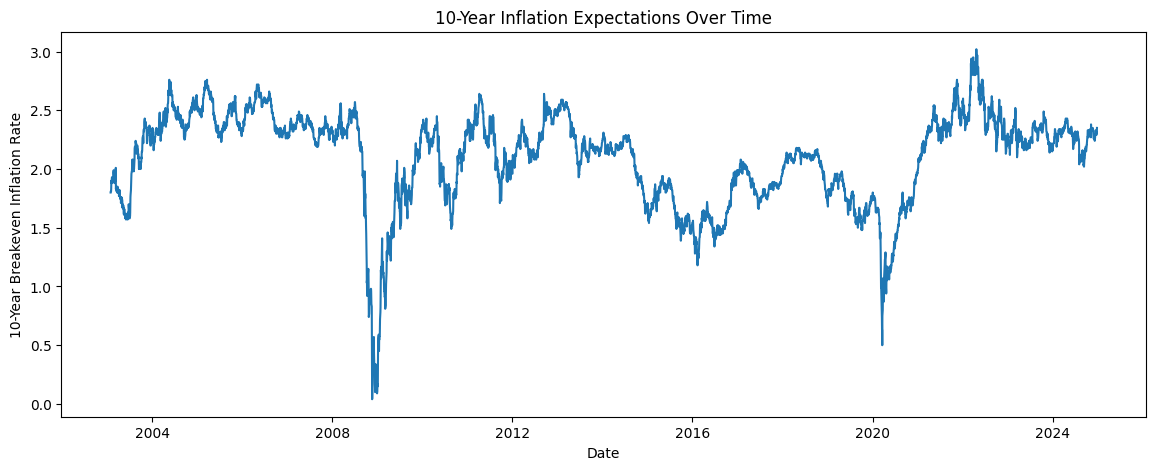

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(df_model.index, df_model['t10yie'])
plt.xlabel('Date')
plt.ylabel('10-Year Breakeven Inflation Rate')
plt.title('10-Year Inflation Expectations Over Time')
plt.show()


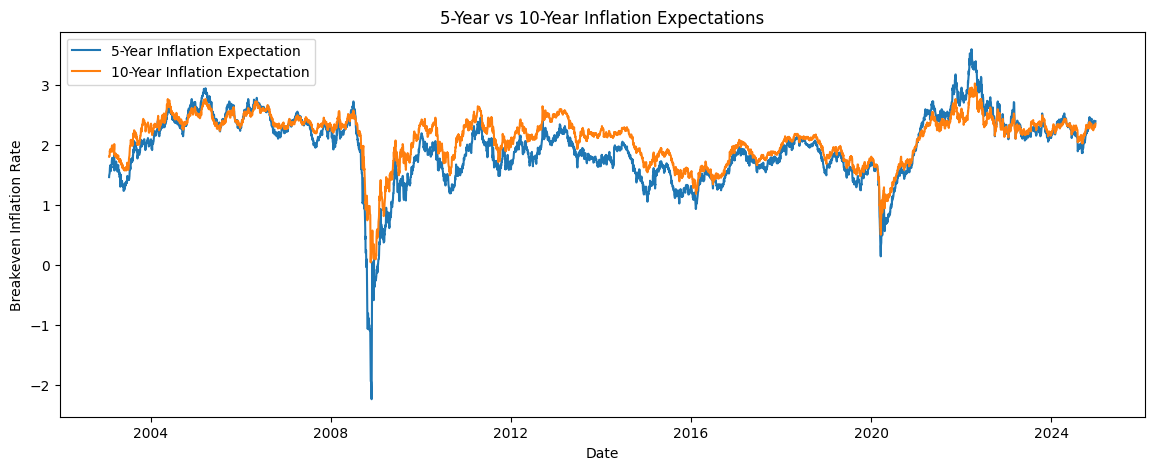

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(df_model.index, df_model['t5yie'], label='5-Year Inflation Expectation')
plt.plot(df_model.index, df_model['t10yie'], label='10-Year Inflation Expectation')
plt.xlabel('Date')
plt.ylabel('Breakeven Inflation Rate')
plt.title('5-Year vs 10-Year Inflation Expectations')
plt.legend()
plt.show()


## target distribution

Regression target

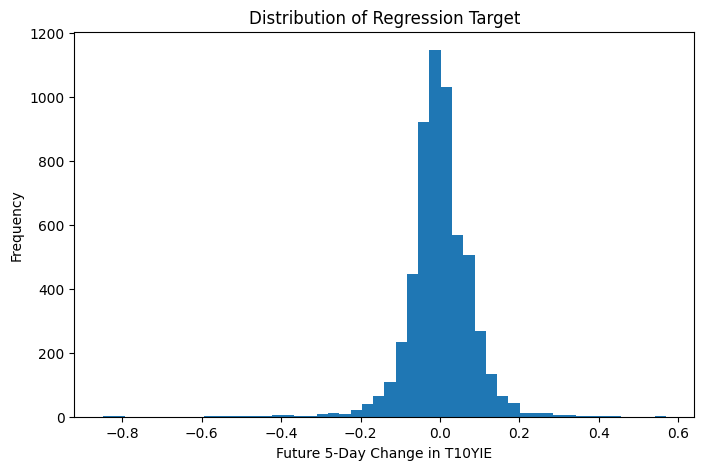

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df_model['target_t10yie_change_5d'], bins=50)
plt.xlabel('Future 5-Day Change in T10YIE')
plt.ylabel('Frequency')
plt.title('Distribution of Regression Target')
plt.show()


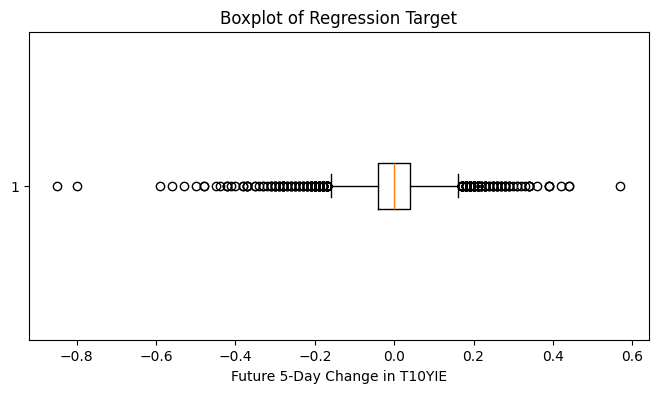

In [24]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_model['target_t10yie_change_5d'], vert=False)
plt.xlabel('Future 5-Day Change in T10YIE')
plt.title('Boxplot of Regression Target')
plt.show()


classification target

In [25]:
class_counts = df_model['target_inflation_risk_5d'].value_counts()
class_counts

,count
target_inflation_risk_5d,
0,3043
1,2671


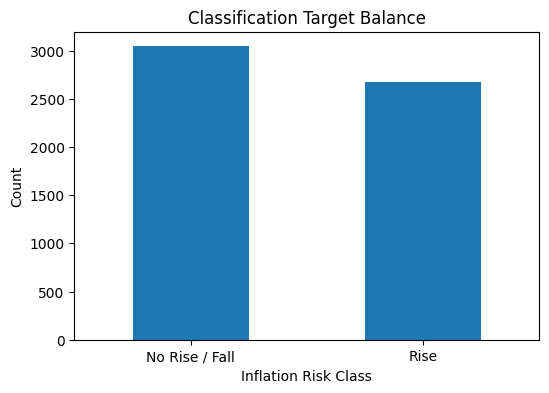

In [26]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.xlabel('Inflation Risk Class')
plt.ylabel('Count')
plt.title('Classification Target Balance')
plt.xticks([0, 1], ['No Rise / Fall', 'Rise'], rotation=0)
plt.show()


##  Feature Trends
These plots show the main economic drivers.

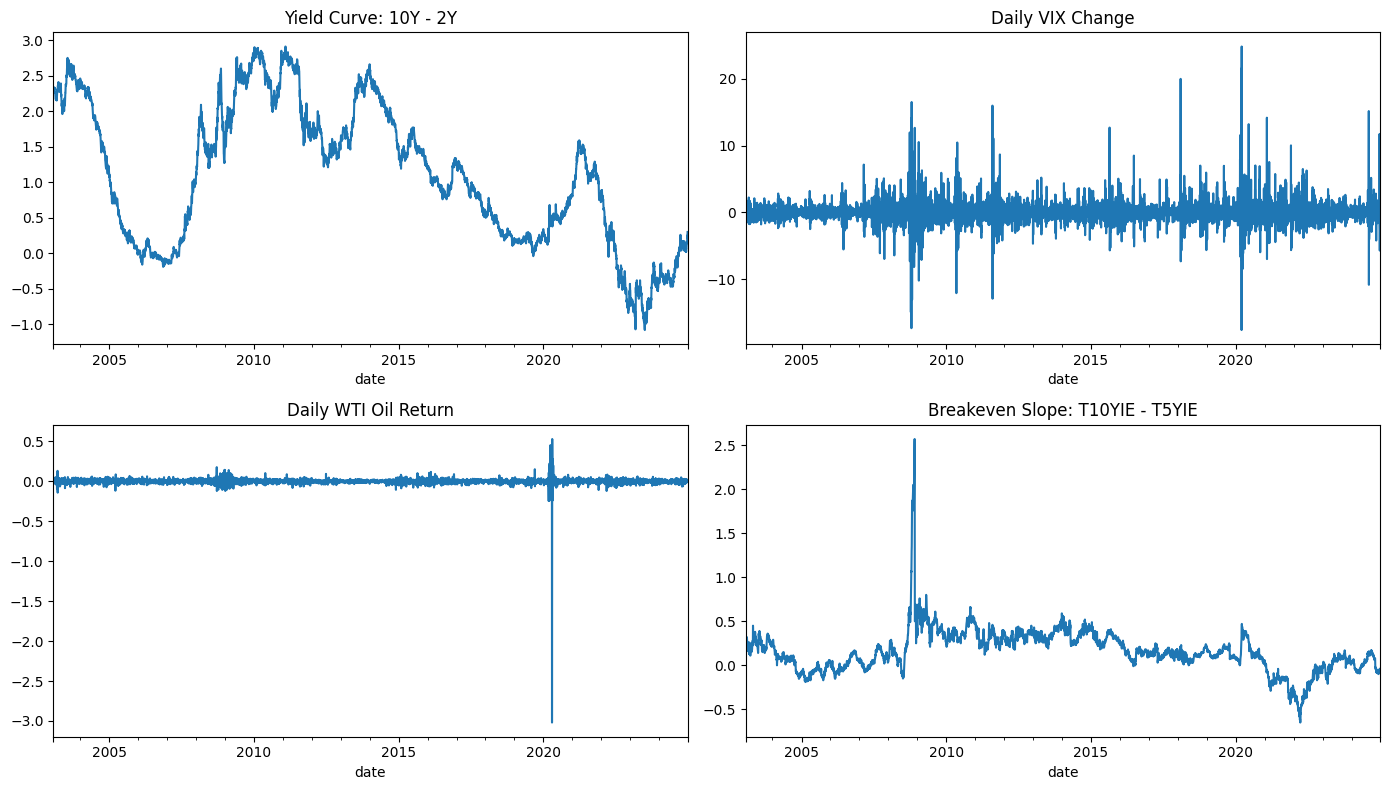

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df_model['yield_curve_10y_2y'].plot(ax=axes[0, 0])
axes[0, 0].set_title('Yield Curve: 10Y - 2Y')

df_model['vix_change_1d'].plot(ax=axes[0, 1])
axes[0, 1].set_title('Daily VIX Change')

df_model['wti_return_1d'].plot(ax=axes[1, 0])
axes[1, 0].set_title('Daily WTI Oil Return')

df_model['breakeven_slope'].plot(ax=axes[1, 1])
axes[1, 1].set_title('Breakeven Slope: T10YIE - T5YIE')

plt.tight_layout()
plt.show()


## correlation

In [28]:
target_corr = (
    df_model
    .corr(numeric_only=True)['target_t10yie_change_5d']
    .drop(['target_t10yie_change_5d', 'target_inflation_risk_5d'])
    .sort_values()
)

target_corr


,target_t10yie_change_5d
t5yifr,-0.136212
t10yie,-0.099152
t5yie,-0.059412
vix_change_1d,-0.044288
canada_usd_return_1d,-0.035210
forward_inflation_gap,-0.024445
breakeven_slope,-0.024198
wti_return_1d,-0.005122
brent_wti_spread,-0.003767
gas_return_5d,-0.000902


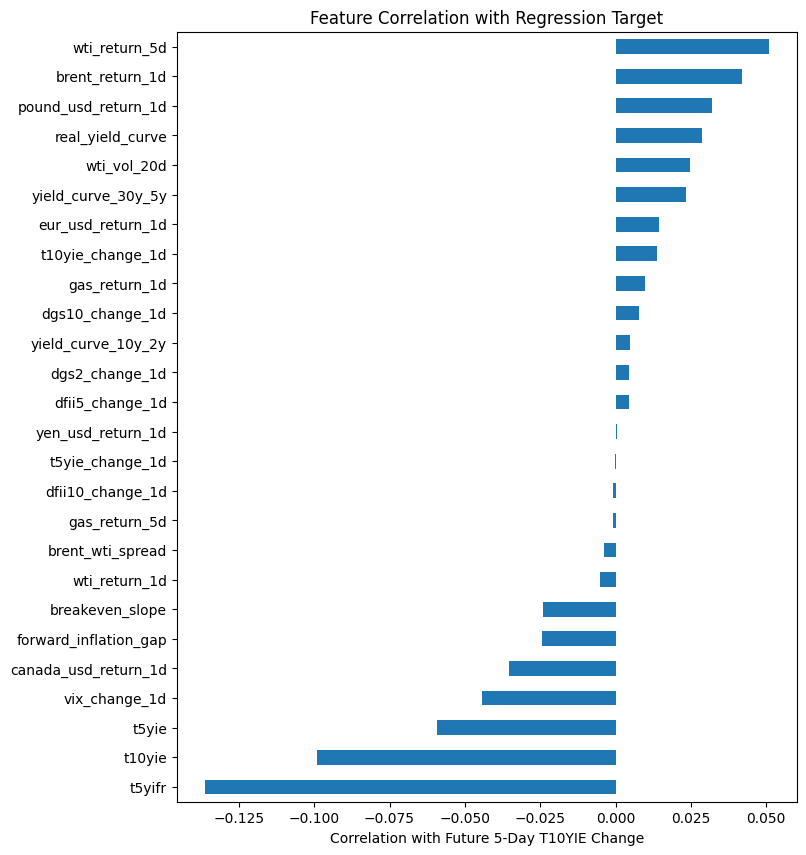

In [29]:
plt.figure(figsize=(8, 10))
target_corr.plot(kind='barh')
plt.xlabel('Correlation with Future 5-Day T10YIE Change')
plt.title('Feature Correlation with Regression Target')
plt.show()


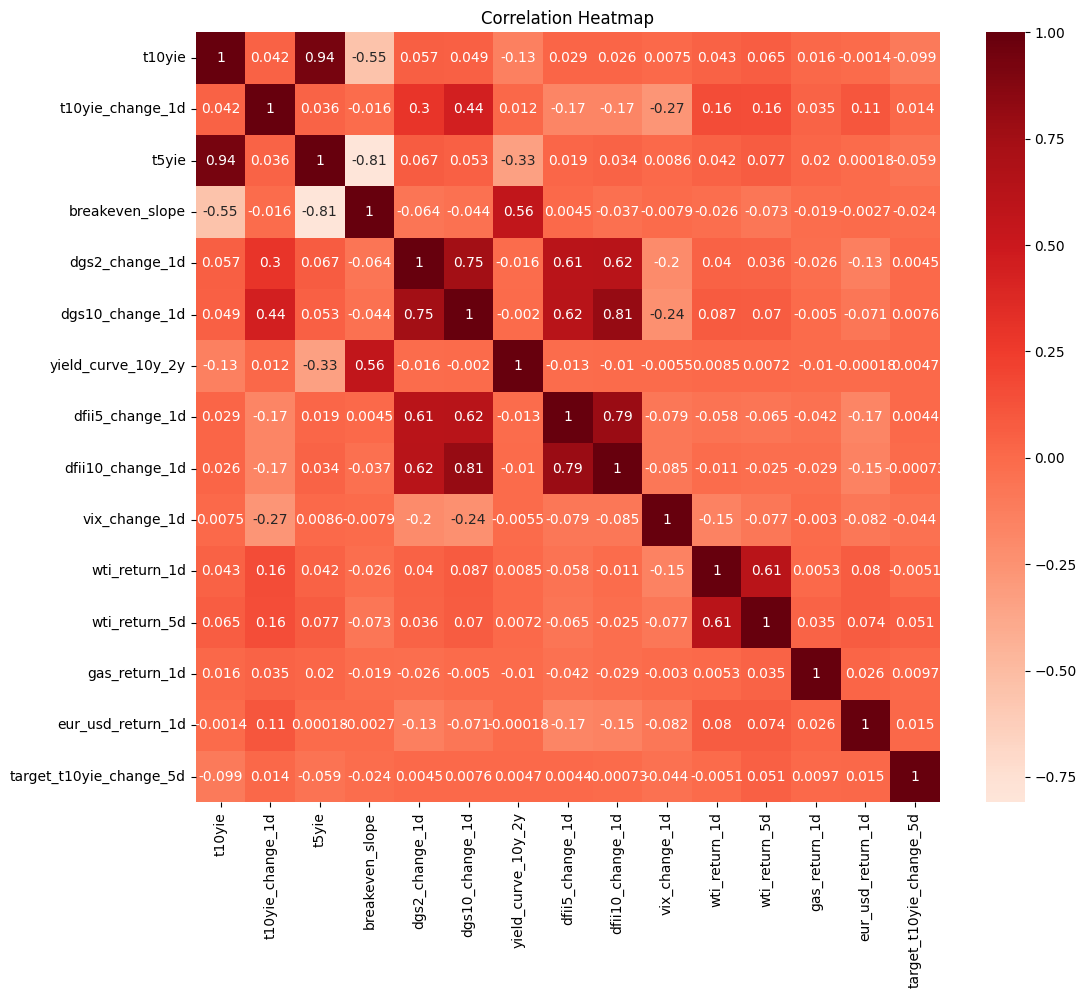

In [30]:
import seaborn as sns

eda_cols = [
    't10yie',
    't10yie_change_1d',
    't5yie',
    'breakeven_slope',
    'dgs2_change_1d',
    'dgs10_change_1d',
    'yield_curve_10y_2y',
    'dfii5_change_1d',
    'dfii10_change_1d',
    'vix_change_1d',
    'wti_return_1d',
    'wti_return_5d',
    'gas_return_1d',
    'eur_usd_return_1d',
    'target_t10yie_change_5d'
]

plt.figure(figsize=(12, 10))
sns.heatmap(df_model[eda_cols].corr(), cmap='Reds', center=0, annot=True)
plt.title('Correlation Heatmap')
plt.show()


##scatterplot against target

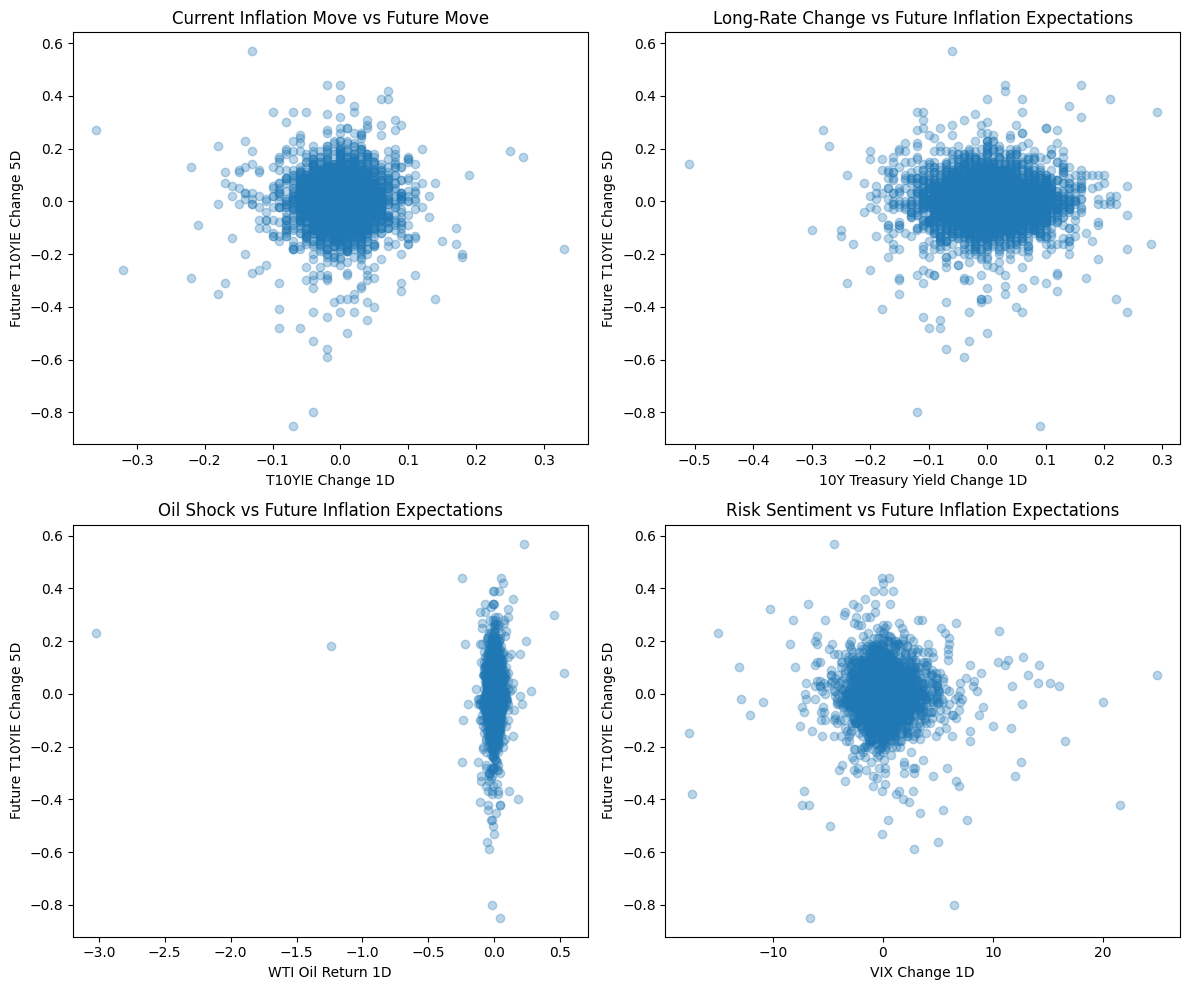

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df_model['t10yie_change_1d'], df_model['target_t10yie_change_5d'], alpha=0.3)
axes[0, 0].set_xlabel('T10YIE Change 1D')
axes[0, 0].set_ylabel('Future T10YIE Change 5D')
axes[0, 0].set_title('Current Inflation Move vs Future Move')

axes[0, 1].scatter(df_model['dgs10_change_1d'], df_model['target_t10yie_change_5d'], alpha=0.3)
axes[0, 1].set_xlabel('10Y Treasury Yield Change 1D')
axes[0, 1].set_ylabel('Future T10YIE Change 5D')
axes[0, 1].set_title('Long-Rate Change vs Future Inflation Expectations')

axes[1, 0].scatter(df_model['wti_return_1d'], df_model['target_t10yie_change_5d'], alpha=0.3)
axes[1, 0].set_xlabel('WTI Oil Return 1D')
axes[1, 0].set_ylabel('Future T10YIE Change 5D')
axes[1, 0].set_title('Oil Shock vs Future Inflation Expectations')

axes[1, 1].scatter(df_model['vix_change_1d'], df_model['target_t10yie_change_5d'], alpha=0.3)
axes[1, 1].set_xlabel('VIX Change 1D')
axes[1, 1].set_ylabel('Future T10YIE Change 5D')
axes[1, 1].set_title('Risk Sentiment vs Future Inflation Expectations')

plt.tight_layout()
plt.show()


## average feature by class(0-not rise,1-rise)
standardlize features first

In [32]:
class_features = [
    't10yie_change_1d',
    'dgs10_change_1d',
    'yield_curve_10y_2y',
    'vix_change_1d',
    'wti_return_1d',
    'gas_return_1d',
    'eur_usd_return_1d'
]

class_feature_means = df_model.groupby('target_inflation_risk_5d')[class_features].mean()

class_feature_means


,t10yie_change_1d,dgs10_change_1d,yield_curve_10y_2y,vix_change_1d,wti_return_1d,gas_return_1d,eur_usd_return_1d
target_inflation_risk_5d,,,,,,,
0,0.000174,0.000325,1.085718,0.002060,-0.000252,0.001207,-0.000139
1,-0.000011,-0.000172,1.106952,-0.008708,0.000024,0.002602,0.000176


In [33]:
standardized = df_model[class_features].copy()

standardized = (
    standardized - standardized.mean()
) / standardized.std()

standardized['target_inflation_risk_5d'] = df_model['target_inflation_risk_5d']

standardized_class_means = standardized.groupby('target_inflation_risk_5d')[class_features].mean()

standardized_class_means


,t10yie_change_1d,dgs10_change_1d,yield_curve_10y_2y,vix_change_1d,wti_return_1d,gas_return_1d,eur_usd_return_1d
target_inflation_risk_5d,,,,,,,
0,0.002578,0.004128,-0.010101,0.002809,-0.002523,-0.009059,-0.026253
1,-0.002937,-0.004702,0.011508,-0.003200,0.002874,0.010321,0.029909


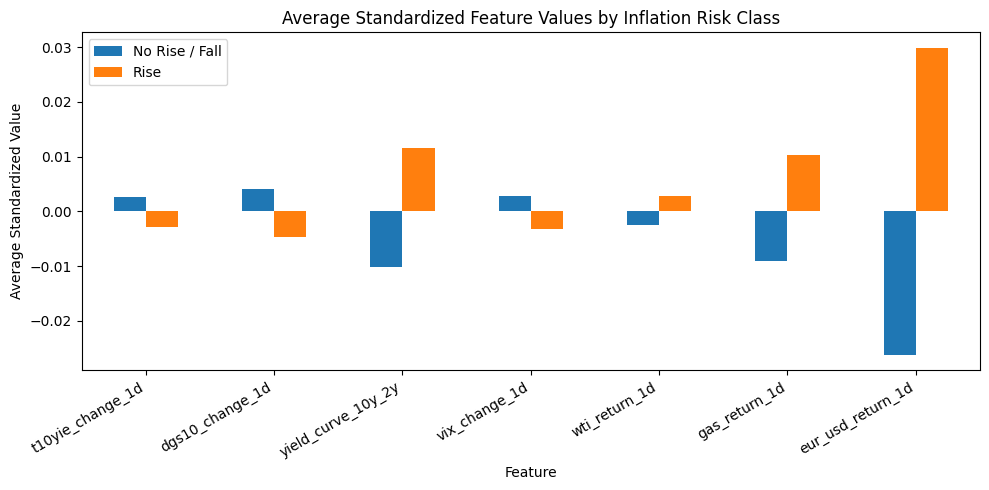

In [34]:
standardized_class_means.T.plot(kind='bar', figsize=(10, 5))

plt.xlabel('Feature')
plt.ylabel('Average Standardized Value')
plt.title('Average Standardized Feature Values by Inflation Risk Class')
plt.xticks(rotation=30, ha='right')
plt.legend(['No Rise / Fall', 'Rise'])
plt.tight_layout()
plt.show()


difference between classes

Positive values mean the feature is higher before inflation expectations rise.

Negative values mean the feature is lower before inflation expectations rise.

Values near zero mean the feature does not separate the two classes much.

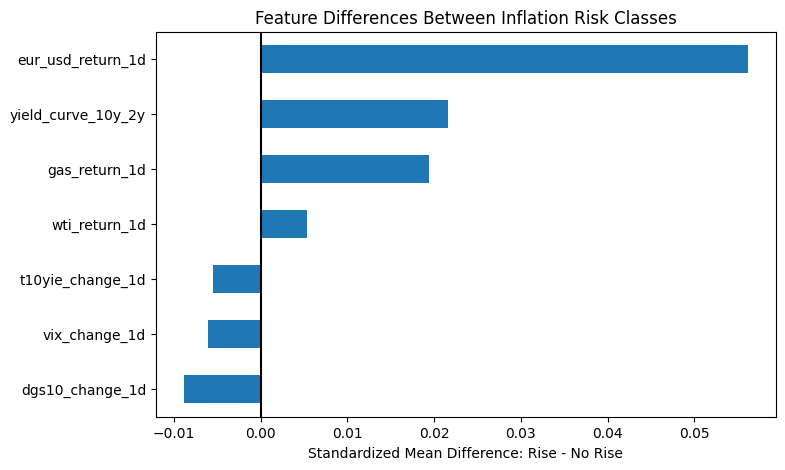

In [35]:
class_mean_difference = (
    standardized_class_means.loc[1]
    - standardized_class_means.loc[0]
).sort_values()

plt.figure(figsize=(8, 5))
class_mean_difference.plot(kind='barh')
plt.axvline(0, color='black')
plt.xlabel('Standardized Mean Difference: Rise - No Rise')
plt.title('Feature Differences Between Inflation Risk Classes')
plt.show()


# 6. Regression

## Baseline model

y_pred is mean of y_train for all x

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline_reg_preds = np.ones(len(y_test_reg)) * y_train_reg.mean()

baseline_reg_mse = mean_squared_error(y_test_reg, baseline_reg_preds)
baseline_reg_rmse = np.sqrt(baseline_reg_mse)
baseline_reg_mae = mean_absolute_error(y_test_reg, baseline_reg_preds)
baseline_reg_r2 = r2_score(y_test_reg, baseline_reg_preds)

print('Baseline Regression MSE:', baseline_reg_mse)
print('Baseline Regression RMSE:', baseline_reg_rmse)
print('Baseline Regression MAE:', baseline_reg_mae)
print('Baseline Regression R^2:', baseline_reg_r2)


Baseline Regression MSE: 0.007217719158089593
Baseline Regression RMSE: 0.08495716072285839
Baseline Regression MAE: 0.060515053501097905
Baseline Regression R^2: -0.0007174364916842091


##  Simple Linear Regression
Use only today’s t10yie_change_1d to predict the next 5-day change.

In [37]:
from sklearn.linear_model import LinearRegression

X_train_simple = X_train[['t10yie_change_1d']]
X_test_simple = X_test[['t10yie_change_1d']]

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train_reg)

simple_reg_preds = simple_lr.predict(X_test_simple)

simple_reg_mse = mean_squared_error(y_test_reg, simple_reg_preds)
simple_reg_rmse = np.sqrt(simple_reg_mse)
simple_reg_mae = mean_absolute_error(y_test_reg, simple_reg_preds)
simple_reg_r2 = r2_score(y_test_reg, simple_reg_preds)

print('Simple Linear Regression MSE:', simple_reg_mse)
print('Simple Linear Regression RMSE:', simple_reg_rmse)
print('Simple Linear Regression MAE:', simple_reg_mae)
print('Simple Linear Regression R^2:', simple_reg_r2)

print('Intercept:', simple_lr.intercept_)
print('Slope:', simple_lr.coef_[0])


Simple Linear Regression MSE: 0.00722359294501066
Simple Linear Regression RMSE: 0.08499172280293335
Simple Linear Regression MAE: 0.06060959123028215
Simple Linear Regression R^2: -0.0015318213217674348
Intercept: -7.382960065150572e-05
Slope: 0.05145178405316783


## Multiple linear regression

In [38]:
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train_reg)

multi_train_preds = multi_lr.predict(X_train)
multi_test_preds = multi_lr.predict(X_test)

multi_reg_mse = mean_squared_error(y_test_reg, multi_test_preds)
multi_reg_rmse = np.sqrt(multi_reg_mse)
multi_reg_mae = mean_absolute_error(y_test_reg, multi_test_preds)
multi_reg_r2 = r2_score(y_test_reg, multi_test_preds)

print('Train RMSE:', np.sqrt(mean_squared_error(y_train_reg, multi_train_preds)))
print('Test RMSE:', multi_reg_rmse)
print('Test MAE:', multi_reg_mae)
print('Test R^2:', multi_reg_r2)


Train RMSE: 0.07608533982353426
Test RMSE: 0.11881833536606658
Test MAE: 0.06943772771592994
Test R^2: -0.9573947298778995


In [39]:
coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': multi_lr.coef_
}).sort_values('coefficient', ascending=False)

coef_table


,feature,coefficient
24,pound_usd_return_1d,0.511353
4,t5yifr,0.348162
6,forward_inflation_gap,0.215968
2,t5yie,0.132193
16,wti_return_5d,0.130112
11,dfii5_change_1d,0.119222
13,real_yield_curve,0.067218
1,t10yie_change_1d,0.051483
20,gas_return_1d,0.037775
3,t5yie_change_1d,0.016396


##  pipeline with scaling

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipe.fit(X_train, y_train_reg)

lr_pipe_preds = lr_pipe.predict(X_test)

lr_pipe_mse = mean_squared_error(y_test_reg, lr_pipe_preds)
lr_pipe_rmse = np.sqrt(lr_pipe_mse)
lr_pipe_mae = mean_absolute_error(y_test_reg, lr_pipe_preds)
lr_pipe_r2 = r2_score(y_test_reg, lr_pipe_preds)

print('Pipeline Linear Regression MSE:', lr_pipe_mse)
print('Pipeline Linear Regression RMSE:', lr_pipe_rmse)
print('Pipeline Linear Regression MAE:', lr_pipe_mae)
print('Pipeline Linear Regression R^2:', lr_pipe_r2)


Pipeline Linear Regression MSE: 0.01411779681916253
Pipeline Linear Regression RMSE: 0.11881833536606431
Pipeline Linear Regression MAE: 0.06943772771592939
Pipeline Linear Regression R^2: -0.9573947298778247


## Linear regression Feature set comparison

In [41]:
feature_groups = {
    'Inflation expectations only': [
        't10yie', 't10yie_change_1d', 't5yie',
        't5yie_change_1d', 't5yifr',
        'breakeven_slope', 'forward_inflation_gap'
    ],
    'Rates and real yields': [
        'dgs2_change_1d', 'dgs10_change_1d',
        'yield_curve_10y_2y', 'yield_curve_30y_5y',
        'dfii5_change_1d', 'dfii10_change_1d',
        'real_yield_curve'
    ],
    'Commodities only': [
        'wti_return_1d', 'wti_return_5d', 'wti_vol_20d',
        'brent_return_1d', 'brent_wti_spread',
        'gas_return_1d', 'gas_return_5d'
    ],
    'Risk and FX': [
        'vix_change_1d',
        'eur_usd_return_1d', 'yen_usd_return_1d',
        'pound_usd_return_1d', 'canada_usd_return_1d'
    ],
    'Full model': X.columns
}


In [42]:
feature_results = []

for group_name, cols in feature_groups.items():
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    model.fit(X_train[cols], y_train_reg)
    preds = model.predict(X_test[cols])

    feature_results.append({
        'feature_group': group_name,
        'test_mse': mean_squared_error(y_test_reg, preds),
        'test_rmse': np.sqrt(mean_squared_error(y_test_reg, preds)),
        'test_mae': mean_absolute_error(y_test_reg, preds),
        'test_r2': r2_score(y_test_reg, preds)
    })

feature_results_df = pd.DataFrame(feature_results).sort_values('test_rmse')
feature_results_df


,feature_group,test_mse,test_rmse,test_mae,test_r2
0,Inflation expectations only,0.007121,0.084388,0.059438,0.012635
1,Rates and real yields,0.007221,0.084974,0.060474,-0.001113
3,Risk and FX,0.007253,0.085162,0.060830,-0.005556
2,Commodities only,0.007441,0.086259,0.061123,-0.031615
4,Full model,0.014118,0.118818,0.069438,-0.957395


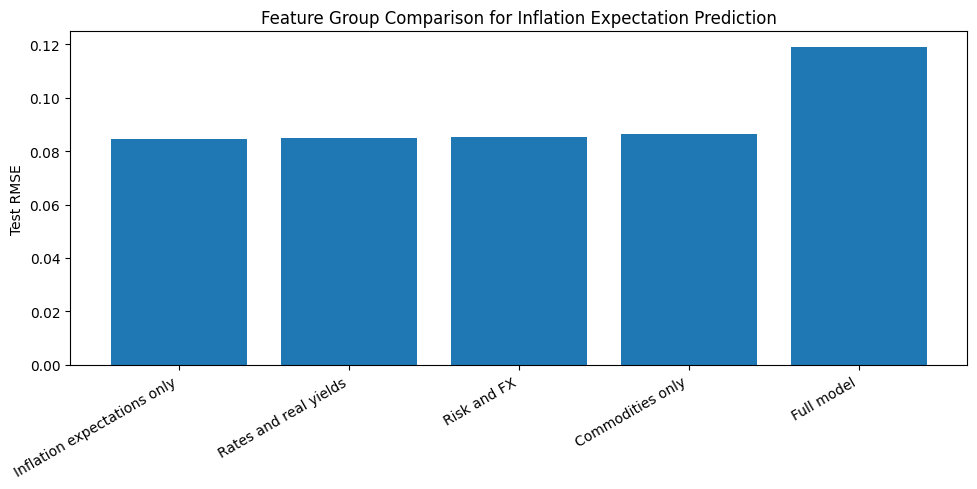

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(feature_results_df['feature_group'], feature_results_df['test_rmse'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Test RMSE')
plt.title('Feature Group Comparison for Inflation Expectation Prediction')
plt.tight_layout()
plt.show()


## knn regressor

n=5

In [44]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

knn_reg_pipe.fit(X_train, y_train_reg)

knn_reg_preds = knn_reg_pipe.predict(X_test)

knn_reg_mse = mean_squared_error(y_test_reg, knn_reg_preds)
knn_reg_rmse = np.sqrt(knn_reg_mse)
knn_reg_mae = mean_absolute_error(y_test_reg, knn_reg_preds)
knn_reg_r2 = r2_score(y_test_reg, knn_reg_preds)

print('KNN Regression MSE:', knn_reg_mse)
print('KNN Regression RMSE:', knn_reg_rmse)
print('KNN Regression MAE:', knn_reg_mae)
print('KNN Regression R^2:', knn_reg_r2)


KNN Regression MSE: 0.008753821538461538
KNN Regression RMSE: 0.09356185942178329
KNN Regression MAE: 0.06624
KNN Regression R^2: -0.2136939187577882


grid search

In [45]:
from sklearn.model_selection import GridSearchCV

knn_reg_grid_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

knn_reg_params = {
    'knn__n_neighbors': range(1,100)
}

knn_reg_grid = GridSearchCV(
    knn_reg_grid_pipe,
    param_grid=knn_reg_params,
    scoring='neg_mean_squared_error',
    cv=5
)

knn_reg_grid.fit(X_train, y_train_reg)

best_knn_reg = knn_reg_grid.best_estimator_
best_knn_reg_preds = best_knn_reg.predict(X_test)

best_knn_reg_mse = mean_squared_error(y_test_reg, best_knn_reg_preds)
best_knn_reg_rmse = np.sqrt(best_knn_reg_mse)
best_knn_reg_mae = mean_absolute_error(y_test_reg, best_knn_reg_preds)
best_knn_reg_r2 = r2_score(y_test_reg, best_knn_reg_preds)

print('Best params:', knn_reg_grid.best_params_)
print('Best KNN Regression RMSE:', best_knn_reg_rmse)
print('Best KNN Regression MAE:', best_knn_reg_mae)
print('Best KNN Regression R^2:', best_knn_reg_r2)


Best params: {'knn__n_neighbors': 99}
Best KNN Regression RMSE: 0.08501117298005591
Best KNN Regression MAE: 0.06062206682206682
Best KNN Regression R^2: -0.0019902706778065493


In [46]:
knn_reg_results = pd.DataFrame(knn_reg_grid.cv_results_)

knn_reg_results['mean_cv_mse'] = -knn_reg_results['mean_test_score']
knn_reg_results['mean_cv_rmse'] = np.sqrt(knn_reg_results['mean_cv_mse'])

knn_reg_results[['param_knn__n_neighbors', 'mean_cv_rmse']].head()


,param_knn__n_neighbors,mean_cv_rmse
0,1,0.099960
1,2,0.089687
2,3,0.086156
3,4,0.083953
4,5,0.083000


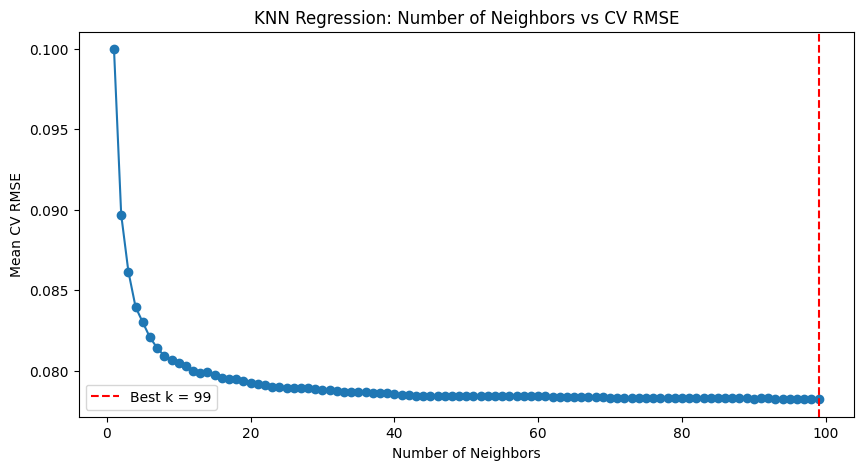

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    knn_reg_results['param_knn__n_neighbors'],
    knn_reg_results['mean_cv_rmse'],
    marker='o'
)

plt.axvline(
    knn_reg_grid.best_params_['knn__n_neighbors'],
    color='red',
    linestyle='--',
    label=f"Best k = {knn_reg_grid.best_params_['knn__n_neighbors']}"
)

plt.xlabel('Number of Neighbors')
plt.ylabel('Mean CV RMSE')
plt.title('KNN Regression: Number of Neighbors vs CV RMSE')
plt.legend()
plt.show()


In [48]:
#check if n is still the largest number on a larger range

from sklearn.model_selection import GridSearchCV

knn_reg_grid_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

knn_reg_params = {
    'knn__n_neighbors': [5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 250, 300]
}

knn_reg_grid = GridSearchCV(
    knn_reg_grid_pipe,
    param_grid=knn_reg_params,
    scoring='neg_mean_squared_error',
    cv=5
)

knn_reg_grid.fit(X_train, y_train_reg)

best_knn_reg = knn_reg_grid.best_estimator_
best_knn_reg_preds = best_knn_reg.predict(X_test)

best_knn_reg_mse = mean_squared_error(y_test_reg, best_knn_reg_preds)
best_knn_reg_rmse = np.sqrt(best_knn_reg_mse)
best_knn_reg_mae = mean_absolute_error(y_test_reg, best_knn_reg_preds)
best_knn_reg_r2 = r2_score(y_test_reg, best_knn_reg_preds)

print('Best params:', knn_reg_grid.best_params_)
print('Best KNN Regression RMSE:', best_knn_reg_rmse)
print('Best KNN Regression MAE:', best_knn_reg_mae)
print('Best KNN Regression R^2:', best_knn_reg_r2)


Best params: {'knn__n_neighbors': 300}
Best KNN Regression RMSE: 0.0849222382963671
Best KNN Regression MAE: 0.06056928205128205
Best KNN Regression R^2: 0.00010510272865993375


The optimal KNN model selected the largest tested neighbor count, suggesting that local nearest-neighbor patterns are weak and that stronger smoothing improves prediction.

In [49]:
best_n=knn_reg_grid.best_params_['knn__n_neighbors']
best_knn_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_n))
])

best_knn_reg.fit(X_train, y_train_reg)

best_knn_reg_preds = best_knn_reg.predict(X_test)

best_knn_reg_mse = mean_squared_error(y_test_reg, best_knn_reg_preds)
best_knn_reg_rmse = np.sqrt(best_knn_reg_mse)
best_knn_reg_mae = mean_absolute_error(y_test_reg, best_knn_reg_preds)
best_knn_reg_r2 = r2_score(y_test_reg, best_knn_reg_preds)

print('Best KNN Regression RMSE:', best_knn_reg_rmse)
print('Best KNN Regression MAE:', best_knn_reg_mae)
print('Best KNN Regression R^2:', best_knn_reg_r2)


Best KNN Regression RMSE: 0.0849222382963671
Best KNN Regression MAE: 0.06056928205128205
Best KNN Regression R^2: 0.00010510272865993375


In [50]:
best_knn_reg_results = pd.DataFrame(knn_reg_grid.cv_results_)

best_knn_reg_results['mean_cv_mse'] = -best_knn_reg_results['mean_test_score']
best_knn_reg_results['mean_cv_rmse'] = np.sqrt(best_knn_reg_results['mean_cv_mse'])

best_knn_reg_results[['param_knn__n_neighbors', 'mean_cv_rmse']]

,param_knn__n_neighbors,mean_cv_rmse
0,5,0.083000
1,10,0.080446
2,20,0.079259
3,30,0.078827
4,50,0.078427
5,75,0.078289
6,100,0.078243
7,125,0.078115
8,150,0.078104
9,200,0.078053


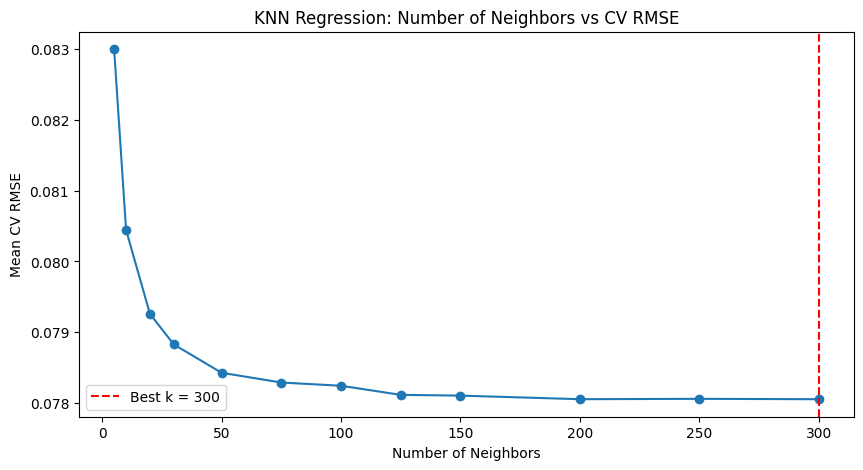

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    best_knn_reg_results['param_knn__n_neighbors'],
    best_knn_reg_results['mean_cv_rmse'],
    marker='o'
)

plt.axvline(
    best_n,
    color='red',
    linestyle='--',
    label=f'Best k = {best_n}'
)

plt.xlabel('Number of Neighbors')
plt.ylabel('Mean CV RMSE')
plt.title('KNN Regression: Number of Neighbors vs CV RMSE')
plt.legend()
plt.show()


Note: the best knn may be larger than 300!


Since the best neighbor count is at the upper edge of the search grid, the true CV optimum may be even larger. However, a very large KNN value also makes the model less local and closer to an average prediction, so we use k = 300 as a practical smoothing choice.

## model comparison


In [52]:
regression_comparison = pd.DataFrame({
    'model': [
        'Baseline Mean',
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Pipeline Linear Regression',
        'KNN Regressor(n=5)',
        'Best KNN Regressor'
    ],
    'test_rmse': [
        baseline_reg_rmse,
        simple_reg_rmse,
        multi_reg_rmse,
        lr_pipe_rmse,
        knn_reg_rmse,
        best_knn_reg_rmse
    ],
    'test_mae': [
        baseline_reg_mae,
        simple_reg_mae,
        multi_reg_mae,
        lr_pipe_mae,
        knn_reg_mae,
        best_knn_reg_mae
    ],
    'test_r2': [
        baseline_reg_r2,
        simple_reg_r2,
        multi_reg_r2,
        lr_pipe_r2,
        knn_reg_r2,
        best_knn_reg_r2
    ]
})

regression_comparison.sort_values('test_rmse')


,model,test_rmse,test_mae,test_r2
5,Best KNN Regressor,0.084922,0.060569,0.000105
0,Baseline Mean,0.084957,0.060515,-0.000717
1,Simple Linear Regression,0.084992,0.060610,-0.001532
4,KNN Regressor(n=5),0.093562,0.066240,-0.213694
3,Pipeline Linear Regression,0.118818,0.069438,-0.957395
2,Multiple Linear Regression,0.118818,0.069438,-0.957395


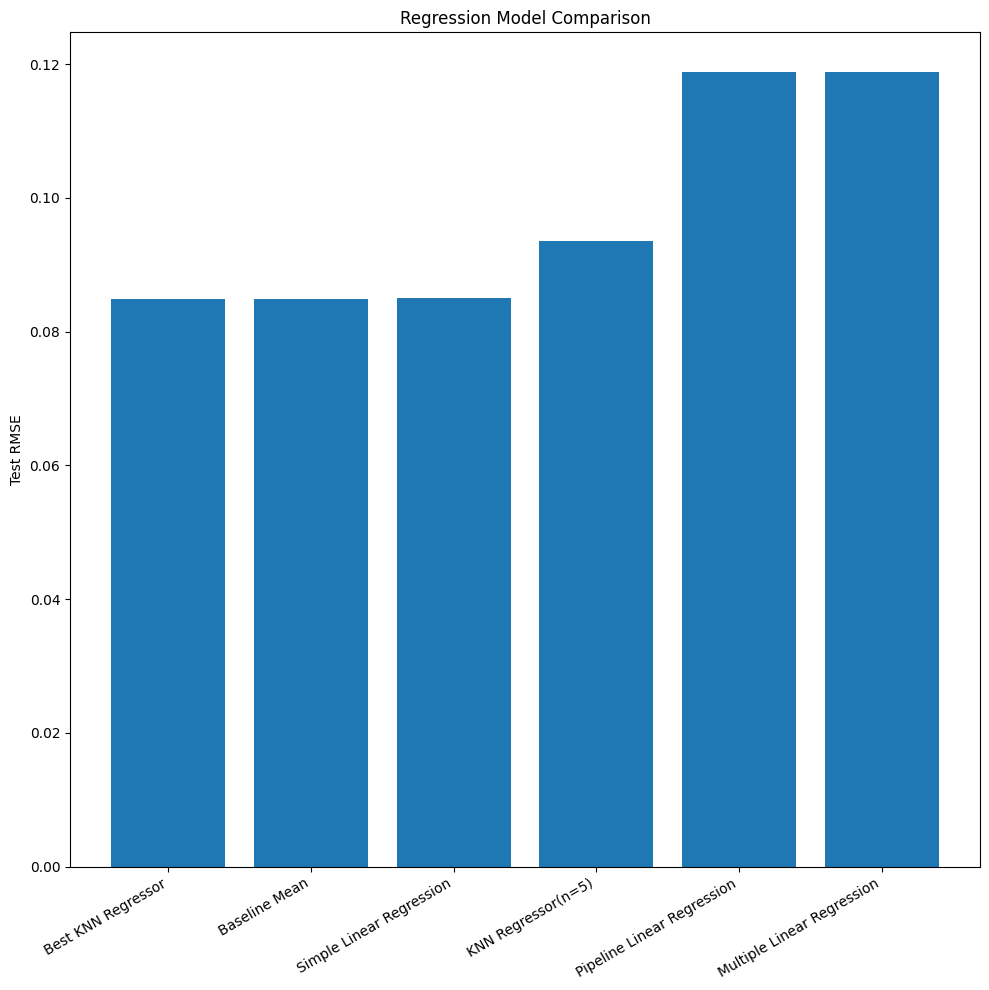

In [53]:
regression_comparison=regression_comparison.sort_values('test_rmse')
plt.figure(figsize=(10, 10))
plt.bar(regression_comparison['model'], regression_comparison['test_rmse'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Test RMSE')
plt.title('Regression Model Comparison')
plt.tight_layout()
plt.show()


# 7. Classification

## baseline

In [54]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train_class)

dummy_preds = dummy.predict(X_test)

baseline_class_accuracy = accuracy_score(y_test_class, dummy_preds)
baseline_class_precision = precision_score(y_test_class, dummy_preds, zero_division=0)
baseline_class_recall = recall_score(y_test_class, dummy_preds, zero_division=0)
baseline_class_f1 = f1_score(y_test_class, dummy_preds, zero_division=0)

print('Baseline Accuracy:', baseline_class_accuracy)
print('Baseline Precision:', baseline_class_precision)
print('Baseline Recall:', baseline_class_recall)
print('Baseline F1:', baseline_class_f1)


Baseline Accuracy: 0.5130769230769231
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


## logistic

Logistic Regression Accuracy: 0.5423076923076923
Logistic Regression Precision: 0.5608974358974359
Logistic Regression Recall: 0.2764612954186414
Logistic Regression F1: 0.37037037037037035


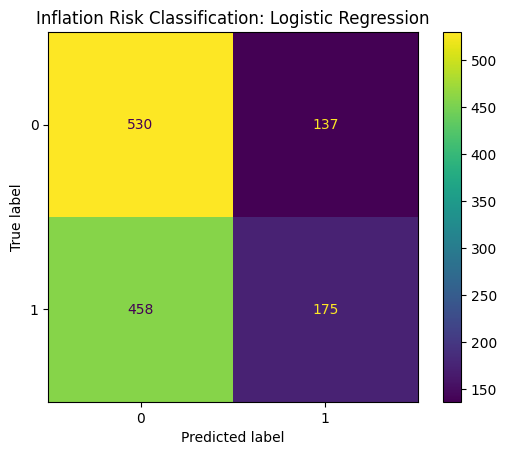

In [55]:
from sklearn.linear_model import LogisticRegression

logit_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logit_pipe.fit(X_train, y_train_class)

logit_preds = logit_pipe.predict(X_test)

logit_accuracy = accuracy_score(y_test_class, logit_preds)
logit_precision = precision_score(y_test_class, logit_preds)
logit_recall = recall_score(y_test_class, logit_preds)
logit_f1 = f1_score(y_test_class, logit_preds)

print('Logistic Regression Accuracy:', logit_accuracy)
print('Logistic Regression Precision:', logit_precision)
print('Logistic Regression Recall:', logit_recall)
print('Logistic Regression F1:', logit_f1)

ConfusionMatrixDisplay.from_estimator(logit_pipe, X_test, y_test_class)
plt.title('Inflation Risk Classification: Logistic Regression')
plt.show()


Threshold: 0.4
Precision: 0.5050279329608939
Recall: 0.7140600315955766
F1: 0.5916230366492147


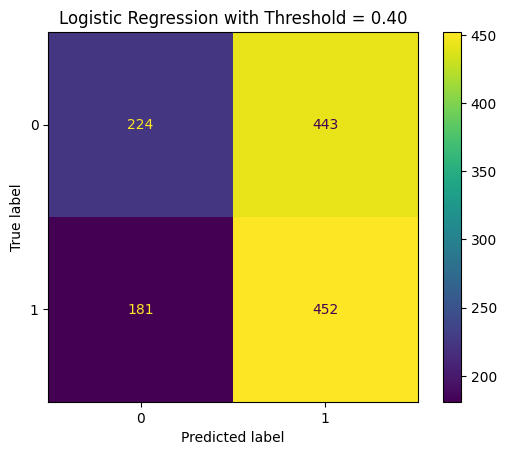

In [56]:
#threshold adjustment if threshold=0.4

logit_probs = logit_pipe.predict_proba(X_test)[:, 1]

threshold = 0.40
threshold_preds = np.where(logit_probs > threshold, 1, 0)

print('Threshold:', threshold)
print('Precision:', precision_score(y_test_class, threshold_preds))
print('Recall:', recall_score(y_test_class, threshold_preds))
print('F1:', f1_score(y_test_class, threshold_preds))

ConfusionMatrixDisplay.from_predictions(y_test_class, threshold_preds)
plt.title('Logistic Regression with Threshold = 0.40')
plt.show()


In [57]:
#find best threshold
validation_split_date = '2018-01-01'

X_train_inner = X_train.loc[X_train.index < validation_split_date]
X_valid = X_train.loc[X_train.index >= validation_split_date]

y_train_inner_class = y_train_class.loc[y_train_class.index < validation_split_date]
y_valid_class = y_train_class.loc[y_train_class.index >= validation_split_date]


In [58]:
logit_threshold_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logit_threshold_pipe.fit(X_train_inner, y_train_inner_class)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [59]:
valid_probs = logit_threshold_pipe.predict_proba(X_valid)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):
    valid_preds = np.where(valid_probs > threshold, 1, 0)

    threshold_results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_valid_class, valid_preds),
        'precision': precision_score(y_valid_class, valid_preds, zero_division=0),
        'recall': recall_score(y_valid_class, valid_preds, zero_division=0),
        'f1': f1_score(y_valid_class, valid_preds, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.sort_values('accuracy', ascending=False).head(10)


,threshold,accuracy,precision,recall,f1
43,0.53,0.611111,0.666667,0.227074,0.338762
40,0.50,0.609195,0.569061,0.449782,0.502439
41,0.51,0.609195,0.588652,0.362445,0.448649
44,0.54,0.603448,0.677419,0.183406,0.288660
42,0.52,0.599617,0.592593,0.279476,0.379822
39,0.49,0.593870,0.539906,0.502183,0.520362
45,0.55,0.588123,0.675000,0.117904,0.200743
38,0.48,0.586207,0.524164,0.615721,0.566265
46,0.56,0.578544,0.655172,0.082969,0.147287
48,0.58,0.572797,0.714286,0.043668,0.082305


In [60]:
best_threshold = (
    threshold_results_df
    .sort_values('accuracy', ascending=False)
    .iloc[0]['threshold']
)

print('Best threshold for accuracy:', best_threshold)


Best threshold for accuracy: 0.5299999999999998


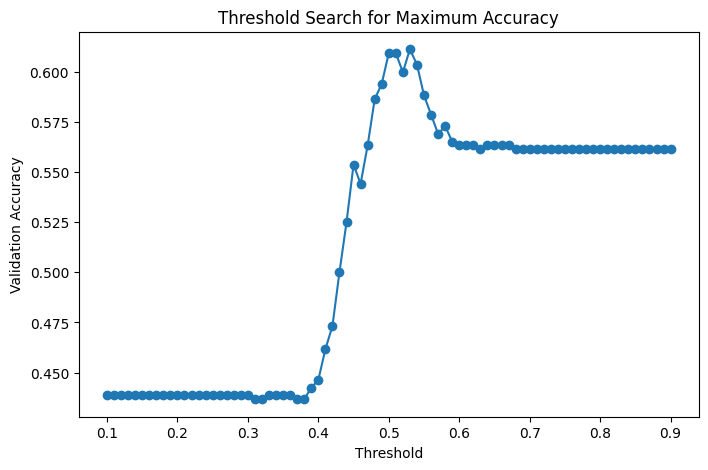

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['accuracy'],
    marker='o'
)
plt.xlabel('Threshold')
plt.ylabel('Validation Accuracy')
plt.title('Threshold Search for Maximum Accuracy')
plt.show()


In [62]:
final_logit_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

final_logit_pipe.fit(X_train, y_train_class)

test_probs = final_logit_pipe.predict_proba(X_test)[:, 1]
best_threshold_preds = np.where(test_probs > best_threshold, 1, 0)

best_threshold_logit_accuracy = accuracy_score(y_test_class, best_threshold_preds)
best_threshold_logit_precision = precision_score(y_test_class, best_threshold_preds, zero_division=0)
best_threshold_logit_recall = recall_score(y_test_class, best_threshold_preds, zero_division=0)
best_threshold_logit_f1 = f1_score(y_test_class, best_threshold_preds, zero_division=0)

print('Best Threshold Logistic Regression Accuracy:', best_threshold_logit_accuracy)
print('Best Threshold Logistic Regression Precision:', best_threshold_logit_precision)
print('Best Threshold Logistic Regression Recall:', best_threshold_logit_recall)
print('Best Threshold Logistic Regression F1:', best_threshold_logit_f1)


Best Threshold Logistic Regression Accuracy: 0.5476923076923077
Best Threshold Logistic Regression Precision: 0.6130653266331658
Best Threshold Logistic Regression Recall: 0.19273301737756715
Best Threshold Logistic Regression F1: 0.2932692307692308


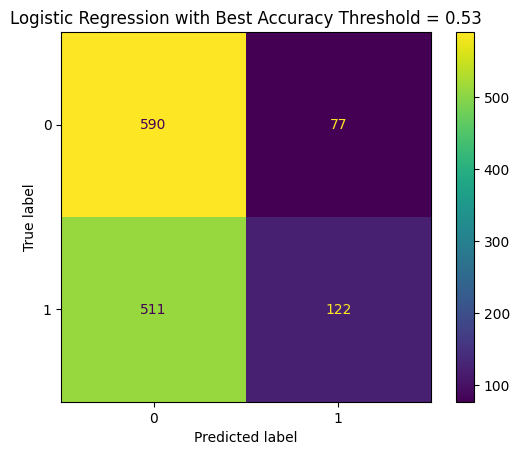

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test_class, best_threshold_preds)
plt.title(f'Logistic Regression with Best Accuracy Threshold = {best_threshold:.2f}')
plt.show()


## knn

KNN Classifier Accuracy: 0.48538461538461536
KNN Classifier Precision: 0.4686411149825784
KNN Classifier Recall: 0.42496050552922593
KNN Classifier F1: 0.44573322286661143


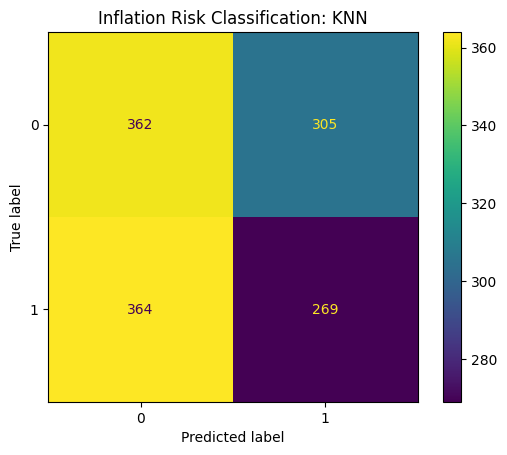

In [64]:
from sklearn.neighbors import KNeighborsClassifier

knn_class_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_class_pipe.fit(X_train, y_train_class)

knn_class_preds = knn_class_pipe.predict(X_test)

knn_class_accuracy = accuracy_score(y_test_class, knn_class_preds)
knn_class_precision = precision_score(y_test_class, knn_class_preds)
knn_class_recall = recall_score(y_test_class, knn_class_preds)
knn_class_f1 = f1_score(y_test_class, knn_class_preds)

print('KNN Classifier Accuracy:', knn_class_accuracy)
print('KNN Classifier Precision:', knn_class_precision)
print('KNN Classifier Recall:', knn_class_recall)
print('KNN Classifier F1:', knn_class_f1)

ConfusionMatrixDisplay.from_estimator(knn_class_pipe, X_test, y_test_class)
plt.title('Inflation Risk Classification: KNN')
plt.show()


In [65]:
#grid search
knn_class_grid_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_class_params = {
    'knn__n_neighbors': [1,2,3, 5, 7, 9, 11, 15, 21, 31]
}

knn_class_grid = GridSearchCV(
    knn_class_grid_pipe,
    param_grid=knn_class_params,
    scoring='f1',
    cv=5
)

knn_class_grid.fit(X_train, y_train_class)

best_knn_class = knn_class_grid.best_estimator_
best_knn_class_preds = best_knn_class.predict(X_test)

best_knn_class_accuracy = accuracy_score(y_test_class, best_knn_class_preds)
best_knn_class_precision = precision_score(y_test_class, best_knn_class_preds)
best_knn_class_recall = recall_score(y_test_class, best_knn_class_preds)
best_knn_class_f1 = f1_score(y_test_class, best_knn_class_preds)

print('Best params:', knn_class_grid.best_params_)
print('Best KNN Accuracy:', best_knn_class_accuracy)
print('Best KNN Precision:', best_knn_class_precision)
print('Best KNN Recall:', best_knn_class_recall)
print('Best KNN F1:', best_knn_class_f1)


Best params: {'knn__n_neighbors': 3}
Best KNN Accuracy: 0.49615384615384617
Best KNN Precision: 0.4804270462633452
Best KNN Recall: 0.4265402843601896
Best KNN F1: 0.45188284518828453


## Model comparison

In [66]:
classification_comparison = pd.DataFrame({
    'model': [
        'Baseline Most Frequent',
        'Logistic Regression',
        'Best Accuracy Threshold Logistic Regression',
        'KNN Classifier',
        'Best KNN Classifier'
    ],
    'accuracy': [
        baseline_class_accuracy,
        logit_accuracy,
        best_threshold_logit_accuracy,
        knn_class_accuracy,
        best_knn_class_accuracy
    ],
    'precision': [
        baseline_class_precision,
        logit_precision,
        best_threshold_logit_precision,
        knn_class_precision,
        best_knn_class_precision
    ],
    'recall': [
        baseline_class_recall,
        logit_recall,
        best_threshold_logit_recall,
        knn_class_recall,
        best_knn_class_recall
    ],
    'f1': [
        baseline_class_f1,
        logit_f1,
        best_threshold_logit_f1,
        knn_class_f1,
        best_knn_class_f1
    ]
})

classification_comparison.sort_values('accuracy', ascending=False)


,model,accuracy,precision,recall,f1
2,Best Accuracy Threshold Logistic Regression,0.547692,0.613065,0.192733,0.293269
1,Logistic Regression,0.542308,0.560897,0.276461,0.370370
0,Baseline Most Frequent,0.513077,0.000000,0.000000,0.000000
4,Best KNN Classifier,0.496154,0.480427,0.426540,0.451883
3,KNN Classifier,0.485385,0.468641,0.424961,0.445733


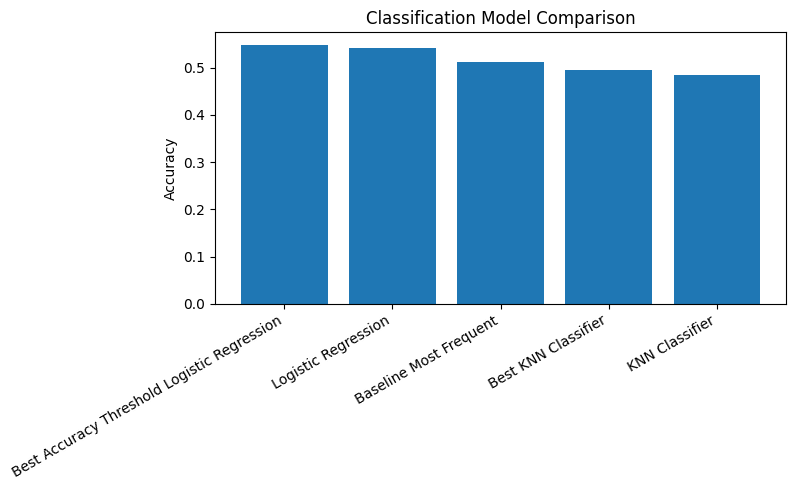

In [67]:
classification_comparison = classification_comparison.sort_values('accuracy', ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(classification_comparison['model'], classification_comparison['accuracy'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Accuracy')
plt.title('Classification Model Comparison')
plt.tight_layout()
plt.show()


# 8. Time series

## sktime extension into regression and classification

In [68]:
# Start from df before selecting df_model
ts_df = df.copy()

In [69]:
#lag
lag_features = [
    't10yie',
    't10yie_change_1d',
    'dgs10_change_1d',
    'dgs2_change_1d',
    'vix_change_1d',
    'wti_return_1d',
    'gas_return_1d',
    'eur_usd_return_1d'
]

for col in lag_features:
    for lag in [1, 2, 3, 5, 10]:
        ts_df[f'{col}_lag{lag}'] = ts_df[col].shift(lag)

#rolling
rolling_features = [
    't10yie_change_1d',
    'dgs10_change_1d',
    'vix_change_1d',
    'wti_return_1d',
    'gas_return_1d'
]

for col in rolling_features:
    ts_df[f'{col}_roll5_mean'] = ts_df[col].rolling(5).mean()
    ts_df[f'{col}_roll5_std'] = ts_df[col].rolling(5).std()
    ts_df[f'{col}_roll20_mean'] = ts_df[col].rolling(20).mean()
    ts_df[f'{col}_roll20_std'] = ts_df[col].rolling(20).std()

#momentum features
ts_df['t10yie_momentum_5d'] = ts_df['t10yie'] - ts_df['t10yie'].shift(5)
ts_df['t10yie_momentum_20d'] = ts_df['t10yie'] - ts_df['t10yie'].shift(20)

ts_df['oil_momentum_5d'] = ts_df['wti_oil'].pct_change(5)
ts_df['oil_momentum_20d'] = ts_df['wti_oil'].pct_change(20)

ts_df['vix_momentum_5d'] = ts_df['vix'] - ts_df['vix'].shift(5)
ts_df['vix_momentum_20d'] = ts_df['vix'] - ts_df['vix'].shift(20)


In [70]:
#time_series dataframe
target_cols = [
    'target_t10yie_change_5d',
    'target_inflation_risk_5d'
]

ts_feature_cols = [
    col for col in ts_df.columns
    if col not in target_cols
]

df_model_ts = ts_df[ts_feature_cols + target_cols].dropna().copy()

print(df_model_ts.shape)
df_model_ts.head()


(5714, 108)


,t10yie,t5yie,t5yifr,dgs2,dgs5,dgs10,dgs30,dfii5,dfii10,vix,...,gas_return_1d_roll20_mean,gas_return_1d_roll20_std,t10yie_momentum_5d,t10yie_momentum_20d,oil_momentum_5d,oil_momentum_20d,vix_momentum_5d,vix_momentum_20d,target_t10yie_change_5d,target_inflation_risk_5d
date,,,,,,,,,,,,,,,,,,,,,
2003-01-30,1.80,1.46,2.14,1.70,3.02,4.00,5.06,1.56,2.20,31.32,...,0.008962,0.049674,0.02,0.16,-0.003540,0.056616,3.79,5.93,0.08,1
2003-01-31,1.81,1.49,2.13,1.72,3.02,4.00,5.03,1.53,2.19,31.17,...,0.005371,0.049865,0.01,0.19,-0.042024,0.007517,-0.34,6.49,0.08,1
2003-02-03,1.81,1.52,2.10,1.72,3.05,4.01,5.01,1.53,2.20,31.02,...,0.008388,0.048981,-0.01,0.18,0.012643,0.017033,-3.67,6.11,0.12,1
2003-02-04,1.84,1.54,2.14,1.68,2.99,3.96,4.99,1.45,2.12,32.76,...,0.013710,0.052519,0.03,0.22,0.027829,0.077244,0.83,7.63,0.09,1
2003-02-05,1.90,1.61,2.19,1.73,3.07,4.02,5.02,1.46,2.12,33.04,...,0.011550,0.052408,0.05,0.19,0.011032,0.106001,1.78,7.51,-0.01,0


In [71]:
#train test split
X_ts = df_model_ts.drop(columns=target_cols)
y_ts_reg = df_model_ts['target_t10yie_change_5d']
y_ts_class = df_model_ts['target_inflation_risk_5d']

split_date = '2020-01-01'

X_train_ts = X_ts.loc[X_ts.index < split_date]
X_test_ts = X_ts.loc[X_ts.index >= split_date]

y_train_ts_reg = y_ts_reg.loc[y_ts_reg.index < split_date]
y_test_ts_reg = y_ts_reg.loc[y_ts_reg.index >= split_date]

y_train_ts_class = y_ts_class.loc[y_ts_class.index < split_date]
y_test_ts_class = y_ts_class.loc[y_ts_class.index >= split_date]


In [72]:
#regression using ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ridge_ts = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ridge_ts.fit(X_train_ts, y_train_ts_reg)

ridge_ts_preds = ridge_ts.predict(X_test_ts)

print('Time-Series Feature Ridge RMSE:', np.sqrt(mean_squared_error(y_test_ts_reg, ridge_ts_preds)))
print('Time-Series Feature Ridge MAE:', mean_absolute_error(y_test_ts_reg, ridge_ts_preds))
print('Time-Series Feature Ridge R^2:', r2_score(y_test_ts_reg, ridge_ts_preds))


Time-Series Feature Ridge RMSE: 0.2652816666143027
Time-Series Feature Ridge MAE: 0.15044570551385703
Time-Series Feature Ridge R^2: -8.757216959400292


In [73]:
#classification using logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logit_ts = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logit_ts.fit(X_train_ts, y_train_ts_class)

logit_ts_preds = logit_ts.predict(X_test_ts)

print('Time-Series Feature Logistic Accuracy:', accuracy_score(y_test_ts_class, logit_ts_preds))
print('Time-Series Feature Logistic Precision:', precision_score(y_test_ts_class, logit_ts_preds))
print('Time-Series Feature Logistic Recall:', recall_score(y_test_ts_class, logit_ts_preds))
print('Time-Series Feature Logistic F1:', f1_score(y_test_ts_class, logit_ts_preds))


Time-Series Feature Logistic Accuracy: 0.5230769230769231
Time-Series Feature Logistic Precision: 0.5970149253731343
Time-Series Feature Logistic Recall: 0.0631911532385466
Time-Series Feature Logistic F1: 0.11428571428571428


## tsfresh extension into regression and classification

In [74]:
#!pip install tsfresh


In [75]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.feature_selection import select_features
from tsfresh.utilities.dataframe_functions import impute


In [76]:
tsfresh_source_cols = [
    't10yie_change_1d',
    'dgs10_change_1d',
    'vix_change_1d',
    'wti_return_1d',
    'gas_return_1d'
]


In [77]:
window_size = 20

window_rows = []
window_targets_reg = []
window_targets_class = []
window_dates = []

for i in range(window_size, len(df)):
    current_date = df.index[i]
    window = df.iloc[i-window_size:i]

    if pd.isna(df.loc[current_date, 'target_t10yie_change_5d']):
        continue

    for time_step, (_, row) in enumerate(window.iterrows()):
        for col in tsfresh_source_cols:
            window_rows.append({
                'id': current_date,
                'time': time_step,
                'kind': col,
                'value': row[col]
            })

    window_dates.append(current_date)
    window_targets_reg.append(df.loc[current_date, 'target_t10yie_change_5d'])
    window_targets_class.append(df.loc[current_date, 'target_inflation_risk_5d'])

tsfresh_long = pd.DataFrame(window_rows)

y_tsfresh_reg = pd.Series(window_targets_reg, index=window_dates, name='target_t10yie_change_5d')
y_tsfresh_class = pd.Series(window_targets_class, index=window_dates, name='target_inflation_risk_5d')

tsfresh_long.head()


,id,time,kind,value
0,2003-01-30,0,t10yie_change_1d,NaN
1,2003-01-30,0,dgs10_change_1d,NaN
2,2003-01-30,0,vix_change_1d,NaN
3,2003-01-30,0,wti_return_1d,NaN
4,2003-01-30,0,gas_return_1d,NaN


In [78]:
# Check missing values
tsfresh_long.isna().sum()


,0
id,0
time,0
kind,0
value,5


In [79]:
# Drop rows where the time-series value is missing
tsfresh_long = tsfresh_long.dropna(subset=['value']).copy()

# Make sure value is numeric
tsfresh_long['value'] = pd.to_numeric(tsfresh_long['value'], errors='coerce')

# Drop any values that became NaN after conversion
tsfresh_long = tsfresh_long.dropna(subset=['value']).copy()

tsfresh_long.isna().sum()


,0
id,0
time,0
kind,0
value,0


In [80]:
X_tsfresh = extract_features(
    tsfresh_long,
    column_id='id',
    column_sort='time',
    column_kind='kind',
    column_value='value',
    default_fc_parameters=MinimalFCParameters(),
    n_jobs=0
)

impute(X_tsfresh)

print(X_tsfresh.shape)
X_tsfresh.head()


Feature Extraction: 100%|██████████| 28570/28570 [00:18<00:00, 1572.65it/s]


(5714, 50)


,dgs10_change_1d__sum_values,dgs10_change_1d__median,dgs10_change_1d__mean,dgs10_change_1d__length,dgs10_change_1d__standard_deviation,dgs10_change_1d__variance,dgs10_change_1d__root_mean_square,dgs10_change_1d__maximum,dgs10_change_1d__absolute_maximum,dgs10_change_1d__minimum,...,wti_return_1d__sum_values,wti_return_1d__median,wti_return_1d__mean,wti_return_1d__length,wti_return_1d__standard_deviation,wti_return_1d__variance,wti_return_1d__root_mean_square,wti_return_1d__maximum,wti_return_1d__absolute_maximum,wti_return_1d__minimum
2003-01-30,-0.01,-0.010,-0.000526,19.0,0.056891,0.003237,0.056893,0.19,0.19,-0.06,...,0.055401,0.008934,0.002916,19.0,0.027703,0.000767,0.027856,0.042074,0.072899,-0.072899
2003-01-31,-0.07,-0.015,-0.003500,20.0,0.056945,0.003243,0.057053,0.19,0.19,-0.06,...,0.062557,0.008630,0.003128,20.0,0.027017,0.000730,0.027198,0.042074,0.072899,-0.072899
2003-02-03,-0.05,-0.005,-0.002500,20.0,0.056822,0.003229,0.056877,0.19,0.19,-0.06,...,0.014214,0.007741,0.000711,20.0,0.025710,0.000661,0.025720,0.042074,0.072899,-0.072899
2003-02-04,-0.08,-0.005,-0.004000,20.0,0.056071,0.003144,0.056214,0.19,0.19,-0.06,...,0.023384,0.007741,0.001169,20.0,0.025251,0.000638,0.025278,0.042074,0.072899,-0.072899
2003-02-05,-0.08,-0.005,-0.004000,20.0,0.056071,0.003144,0.056214,0.19,0.19,-0.06,...,0.080587,0.008630,0.004029,20.0,0.024357,0.000593,0.024688,0.042074,0.072899,-0.072899


In [81]:
X_tsfresh_reg_selected = select_features(
    X_tsfresh,
    y_tsfresh_reg
)

print(X_tsfresh_reg_selected.shape)
X_tsfresh_reg_selected.head()


(5714, 8)


,wti_return_1d__mean,wti_return_1d__sum_values,wti_return_1d__median,gas_return_1d__root_mean_square,gas_return_1d__variance,gas_return_1d__standard_deviation,gas_return_1d__minimum,dgs10_change_1d__median
2003-01-30,0.002916,0.055401,0.008934,0.050144,0.002450,0.049498,-0.09771,-0.010
2003-01-31,0.003128,0.062557,0.008630,0.049239,0.002344,0.048416,-0.09771,-0.015
2003-02-03,0.000711,0.014214,0.007741,0.048898,0.002362,0.048602,-0.09771,-0.005
2003-02-04,0.001169,0.023384,0.007741,0.048472,0.002279,0.047741,-0.09771,-0.005
2003-02-05,0.004029,0.080587,0.008630,0.052994,0.002620,0.051190,-0.09771,-0.005


In [82]:
X_tsfresh_class_selected = select_features(
    X_tsfresh,
    y_tsfresh_class
)

print(X_tsfresh_class_selected.shape)
X_tsfresh_class_selected.head()


(5714, 7)


,wti_return_1d__mean,wti_return_1d__sum_values,wti_return_1d__median,gas_return_1d__root_mean_square,gas_return_1d__variance,gas_return_1d__standard_deviation,gas_return_1d__minimum
2003-01-30,0.002916,0.055401,0.008934,0.050144,0.002450,0.049498,-0.09771
2003-01-31,0.003128,0.062557,0.008630,0.049239,0.002344,0.048416,-0.09771
2003-02-03,0.000711,0.014214,0.007741,0.048898,0.002362,0.048602,-0.09771
2003-02-04,0.001169,0.023384,0.007741,0.048472,0.002279,0.047741,-0.09771
2003-02-05,0.004029,0.080587,0.008630,0.052994,0.002620,0.051190,-0.09771


In [83]:
#train test split
split_date = '2020-01-01'

X_train_tsfresh_reg = X_tsfresh_reg_selected.loc[X_tsfresh_reg_selected.index < split_date]
X_test_tsfresh_reg = X_tsfresh_reg_selected.loc[X_tsfresh_reg_selected.index >= split_date]

y_train_tsfresh_reg = y_tsfresh_reg.loc[y_tsfresh_reg.index < split_date]
y_test_tsfresh_reg = y_tsfresh_reg.loc[y_tsfresh_reg.index >= split_date]

X_train_tsfresh_class = X_tsfresh_class_selected.loc[X_tsfresh_class_selected.index < split_date]
X_test_tsfresh_class = X_tsfresh_class_selected.loc[X_tsfresh_class_selected.index >= split_date]

y_train_tsfresh_class = y_tsfresh_class.loc[y_tsfresh_class.index < split_date]
y_test_tsfresh_class = y_tsfresh_class.loc[y_tsfresh_class.index >= split_date]


In [84]:
#regression
ridge_tsfresh = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ridge_tsfresh.fit(X_train_tsfresh_reg, y_train_tsfresh_reg)

tsfresh_reg_preds = ridge_tsfresh.predict(X_test_tsfresh_reg)

print('tsfresh Ridge RMSE:', np.sqrt(mean_squared_error(y_test_tsfresh_reg, tsfresh_reg_preds)))
print('tsfresh Ridge MAE:', mean_absolute_error(y_test_tsfresh_reg, tsfresh_reg_preds))
print('tsfresh Ridge R^2:', r2_score(y_test_tsfresh_reg, tsfresh_reg_preds))


tsfresh Ridge RMSE: 0.1069274022877639
tsfresh Ridge MAE: 0.07076384887977478
tsfresh Ridge R^2: -0.5852199147054562


In [85]:
#classification
logit_tsfresh = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logit_tsfresh.fit(X_train_tsfresh_class, y_train_tsfresh_class)

tsfresh_class_preds = logit_tsfresh.predict(X_test_tsfresh_class)

print('tsfresh Logistic Accuracy:', accuracy_score(y_test_tsfresh_class, tsfresh_class_preds))
print('tsfresh Logistic Precision:', precision_score(y_test_tsfresh_class, tsfresh_class_preds))
print('tsfresh Logistic Recall:', recall_score(y_test_tsfresh_class, tsfresh_class_preds))
print('tsfresh Logistic F1:', f1_score(y_test_tsfresh_class, tsfresh_class_preds))


tsfresh Logistic Accuracy: 0.5415384615384615
tsfresh Logistic Precision: 0.5408388520971302
tsfresh Logistic Recall: 0.38704581358609796
tsfresh Logistic F1: 0.45119705340699817


## time series model

In [88]:
!pip install sktime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.4 MB/s eta 0:00:00


In [89]:
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.transformations.series.detrend import Deseasonalizer
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanSquaredPercentageError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [90]:
#target
y_ts = df['t10yie'].copy()

# Make sure index is business-day frequency
y_ts = y_ts.asfreq('B')

# Fill small gaps from holidays
y_ts = y_ts.ffill()

# Drop remaining missing values
y_ts = y_ts.dropna()

print(y_ts.shape)
y_ts.head()


(5739,)


,t10yie
date,
2003-01-02,1.64
2003-01-03,1.62
2003-01-06,1.63
2003-01-07,1.62
2003-01-08,1.71


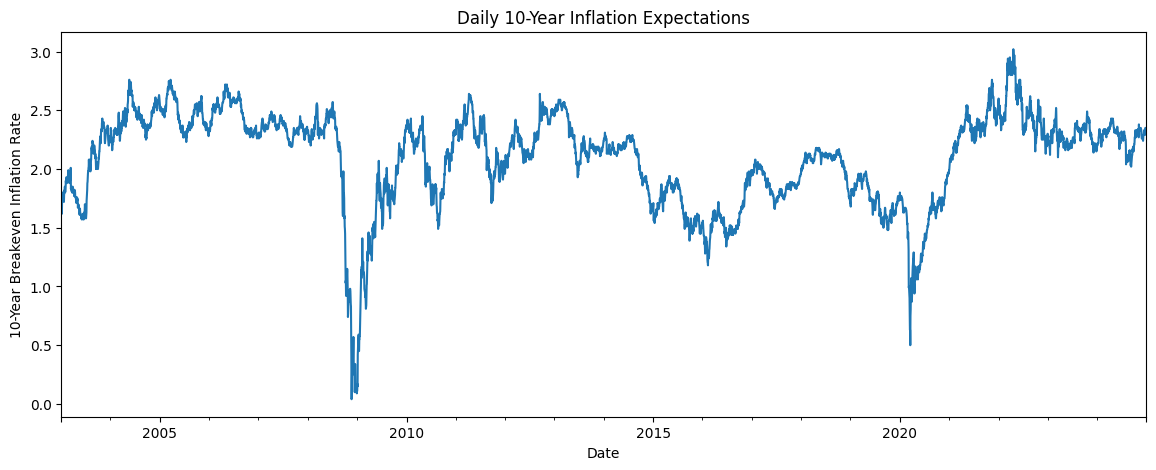

In [91]:
plt.figure(figsize=(14, 5))
y_ts.plot()
plt.xlabel('Date')
plt.ylabel('10-Year Breakeven Inflation Rate')
plt.title('Daily 10-Year Inflation Expectations')
plt.show()


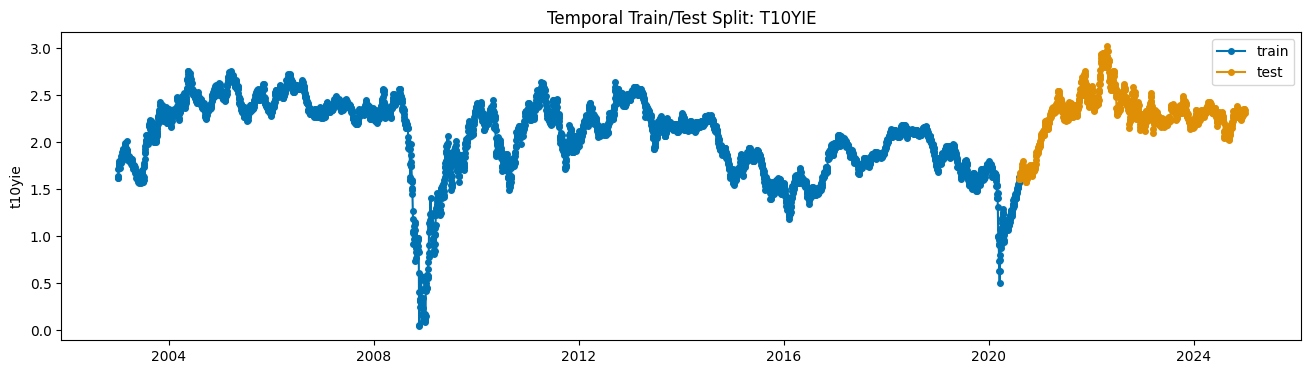

In [92]:
#train test split
y_train_ts, y_test_ts = temporal_train_test_split(
    y_ts,
    test_size=0.2
)

plot_series(y_train_ts, y_test_ts, labels=['train', 'test'])
plt.title('Temporal Train/Test Split: T10YIE')
plt.show()


In [93]:
fh = np.arange(1, len(y_test_ts) + 1)

fh[:10], len(fh)


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), 1148)

In [94]:
mape = MeanAbsolutePercentageError()
rmspe = MeanSquaredPercentageError(square_root=True)


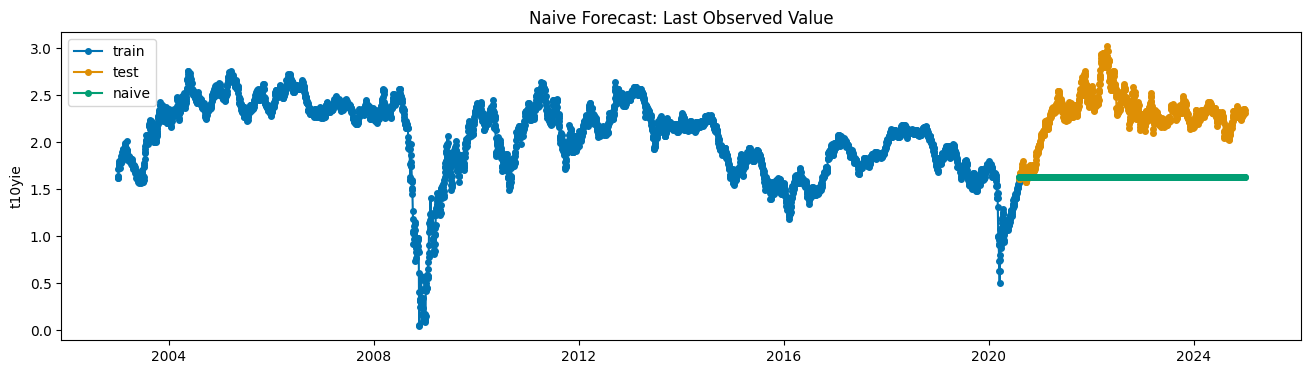

Naive MAPE: 0.2831809212518754
Naive RMSPE: 0.29561769804081295


In [95]:
naive = NaiveForecaster(strategy='last')
naive.fit(y_train_ts)

naive_preds = naive.predict(fh)

plot_series(y_train_ts, y_test_ts, naive_preds, labels=['train', 'test', 'naive'])
plt.title('Naive Forecast: Last Observed Value')
plt.show()

print('Naive MAPE:', mape(y_test_ts, naive_preds))
print('Naive RMSPE:', rmspe(y_test_ts, naive_preds))


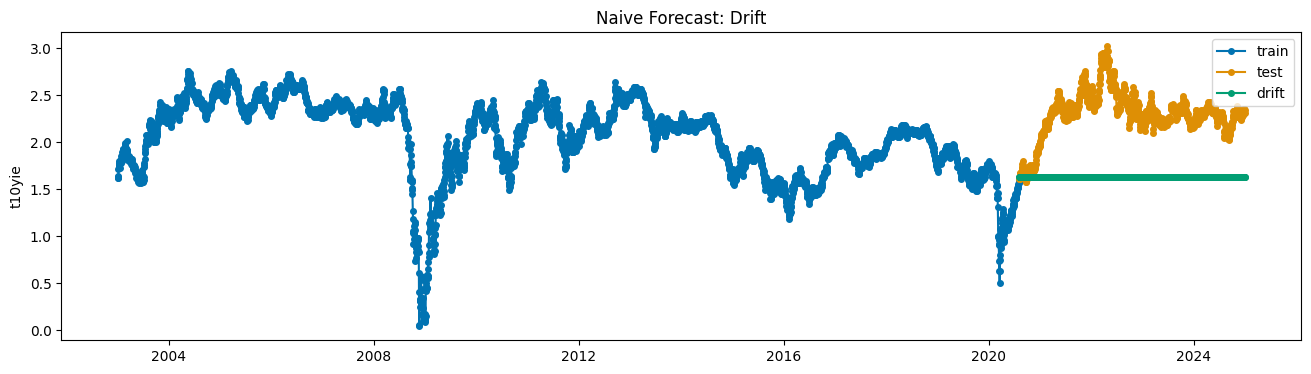

Drift MAPE: 0.2837207500451522
Drift RMSPE: 0.2961536382633721


In [96]:
drift = NaiveForecaster(strategy='drift')
drift.fit(y_train_ts)

drift_preds = drift.predict(fh)

plot_series(y_train_ts, y_test_ts, drift_preds, labels=['train', 'test', 'drift'])
plt.title('Naive Forecast: Drift')
plt.show()

print('Drift MAPE:', mape(y_test_ts, drift_preds))
print('Drift RMSPE:', rmspe(y_test_ts, drift_preds))


/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)


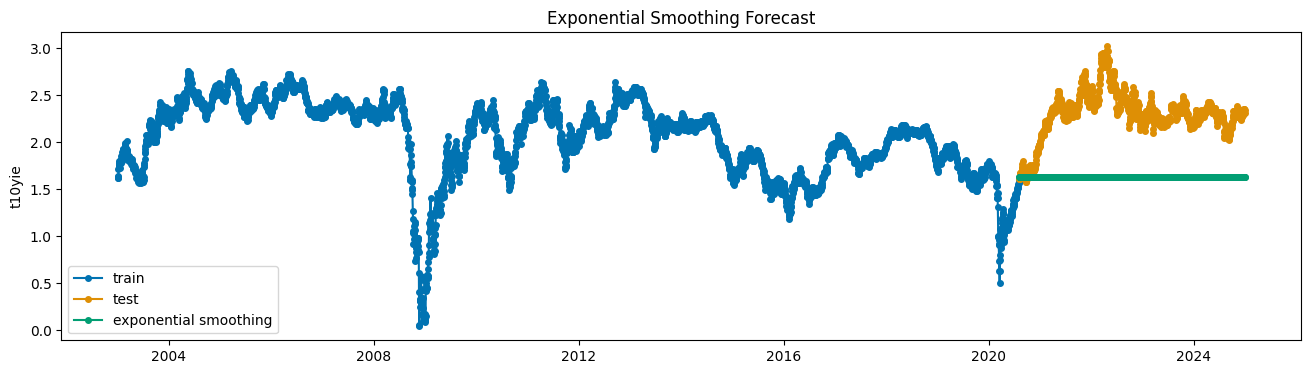

Exponential Smoothing MAPE: 0.2831809213800692
Exponential Smoothing RMSPE: 0.2956176981617591


In [97]:
exp = ExponentialSmoothing()
exp.fit(y_train_ts)

exp_preds = exp.predict(fh)

plot_series(y_train_ts, y_test_ts, exp_preds, labels=['train', 'test', 'exponential smoothing'])
plt.title('Exponential Smoothing Forecast')
plt.show()

print('Exponential Smoothing MAPE:', mape(y_test_ts, exp_preds))
print('Exponential Smoothing RMSPE:', rmspe(y_test_ts, exp_preds))


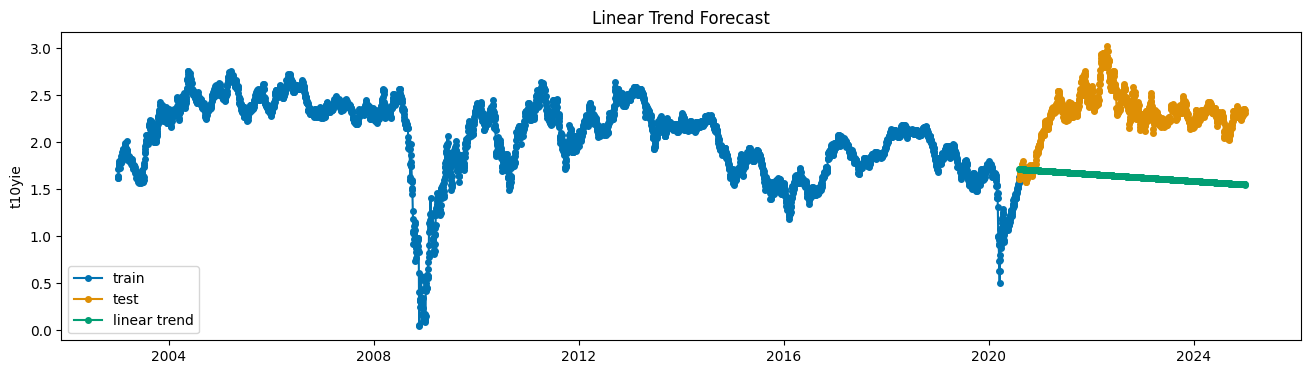

Linear Trend MAPE: 0.2846064201249574
Linear Trend RMSPE: 0.2980949540907438


In [98]:
trend = PolynomialTrendForecaster(degree=1)
trend.fit(y_train_ts)

trend_preds = trend.predict(fh)

plot_series(y_train_ts, y_test_ts, trend_preds, labels=['train', 'test', 'linear trend'])
plt.title('Linear Trend Forecast')
plt.show()

print('Linear Trend MAPE:', mape(y_test_ts, trend_preds))
print('Linear Trend RMSPE:', rmspe(y_test_ts, trend_preds))


Holt-Winters / Exponential Smoothing

For daily financial data, I would try no seasonality first.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)


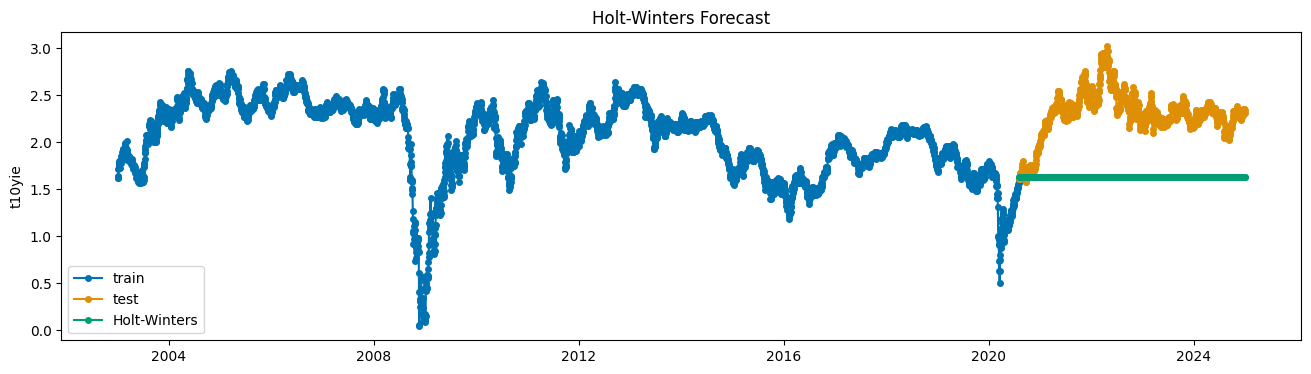

In [99]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

holt_winters = ExponentialSmoothing(
    trend='add',
    seasonal=None
)

holt_winters.fit(y_train_ts)

hw_preds = holt_winters.predict(fh)

plot_series(y_train_ts, y_test_ts, hw_preds, labels=['train', 'test', 'Holt-Winters'])
plt.title('Holt-Winters Forecast')
plt.show()


/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)


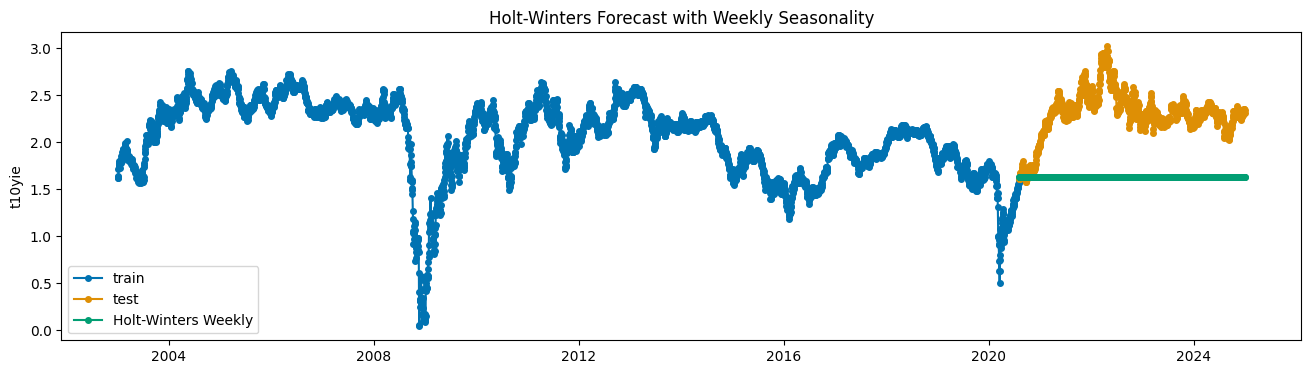

In [100]:
holt_winters_weekly = ExponentialSmoothing(
    trend='add',
    seasonal='add',
    sp=5
)

holt_winters_weekly.fit(y_train_ts)

hw_weekly_preds = holt_winters_weekly.predict(fh)

plot_series(
    y_train_ts,
    y_test_ts,
    hw_weekly_preds,
    labels=['train', 'test', 'Holt-Winters Weekly']
)
plt.title('Holt-Winters Forecast with Weekly Seasonality')
plt.show()


AutoREG


AutoREG uses lagged values of t10yie to predict future values.

In [101]:
from sktime.forecasting.auto_reg import AutoREG

In [102]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sklearn.metrics import mean_squared_error, mean_absolute_error

mape = MeanAbsolutePercentageError()

def evaluate_forecast(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'mape': mape(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred)
    }


In [103]:
autoreg_results = []
autoreg_predictions = {}

for lags in [5, 10, 20, 60]:
    model = AutoREG(lags=lags)
    model.fit(y_train_ts)
    preds = model.predict(fh)

    autoreg_predictions[f'AutoREG lags={lags}'] = preds
    autoreg_results.append(
        evaluate_forecast(y_test_ts, preds, f'AutoREG lags={lags}')
    )

pd.DataFrame(autoreg_results).sort_values('mape')


/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/bas

,model,mape,rmse,mae
3,AutoREG lags=60,0.127721,0.354186,0.306821
2,AutoREG lags=20,0.143810,0.398961,0.346478
0,AutoREG lags=5,0.150038,0.416425,0.361449
1,AutoREG lags=10,0.152103,0.420988,0.366297


/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return x.to_period(freq)


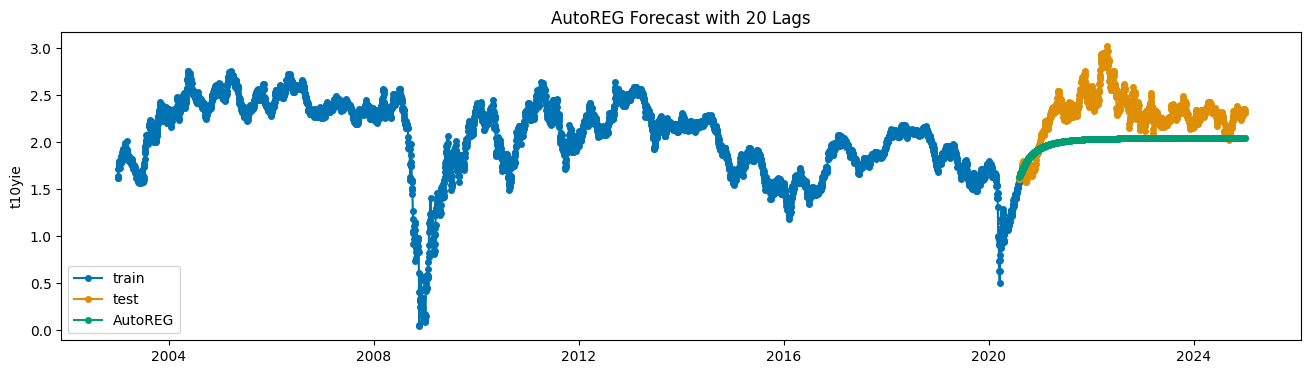

In [104]:
autoreg = AutoREG(lags=60)
autoreg.fit(y_train_ts)

autoreg_preds = autoreg.predict(fh)

plot_series(y_train_ts, y_test_ts, autoreg_preds, labels=['train', 'test', 'AutoREG'])
plt.title('AutoREG Forecast with 20 Lags')
plt.show()


Arima

In [105]:
#test using Arima(1,1,1)
from statsmodels.tsa.arima.model import ARIMA as StatsmodelsARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
arima_111 = StatsmodelsARIMA(
    y_train_ts,
    order=(1, 1, 1)
)

arima_111_fit = arima_111.fit()



In [106]:
def evaluate_ts_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))

    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'mape': mape
    }

In [107]:
arima_111_preds = arima_111_fit.forecast(steps=len(y_test_ts))

# Give forecast the same date index as test data
arima_111_preds.index = y_test_ts.index

arima_111_results = evaluate_ts_forecast(
    y_test_ts,
    arima_111_preds,
    'ARIMA(1,1,1)'
)

arima_111_results


{'model': 'ARIMA(1,1,1)',
 'rmse': np.float64(0.7138000478500842),
 'mae': 0.6708876913705679,
 'mape': np.float64(0.282591830127113)}

In [108]:
#try multiple
arima_orders = [
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (2, 1, 2),
    (5, 1, 1)
]

arima_results = []
arima_predictions = {}

for order in arima_orders:
    model_name = f'ARIMA{order}'

    try:
        model = StatsmodelsARIMA(
            y_train_ts,
            order=order
        )

        fitted_model = model.fit()
        preds = fitted_model.forecast(steps=len(y_test_ts))
        preds.index = y_test_ts.index

        arima_predictions[model_name] = preds
        arima_results.append(
            evaluate_ts_forecast(y_test_ts, preds, model_name)
        )

        print(f'Finished {model_name}')

    except Exception as e:
        print(f'{model_name} failed')
        print(e)

arima_results_df = pd.DataFrame(arima_results).sort_values('rmse')
arima_results_df


Finished ARIMA(1, 1, 0)
Finished ARIMA(1, 1, 1)
Finished ARIMA(2, 1, 1)
Finished ARIMA(2, 1, 2)
Finished ARIMA(5, 1, 1)


,model,rmse,mae,mape
3,"ARIMA(2, 1, 2)",0.697323,0.653927,0.275234
0,"ARIMA(1, 1, 0)",0.712360,0.669386,0.281937
1,"ARIMA(1, 1, 1)",0.713800,0.670888,0.282592
2,"ARIMA(2, 1, 1)",0.714273,0.671381,0.282807
4,"ARIMA(5, 1, 1)",0.718127,0.675416,0.284570


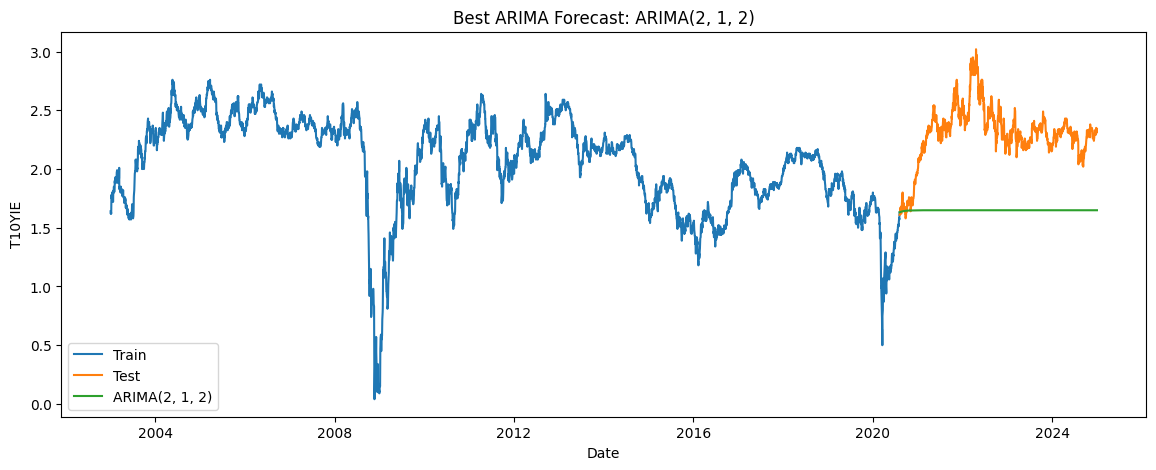

In [109]:
#plot best one
best_arima_name = arima_results_df.iloc[0]['model']
best_arima_preds = arima_predictions[best_arima_name]

plt.figure(figsize=(14, 5))
plt.plot(y_train_ts, label='Train')
plt.plot(y_test_ts, label='Test')
plt.plot(best_arima_preds, label=best_arima_name)
plt.xlabel('Date')
plt.ylabel('T10YIE')
plt.title(f'Best ARIMA Forecast: {best_arima_name}')
plt.legend()
plt.show()

Model comparison

In [110]:
forecast_results = []

forecast_results.append(evaluate_forecast(y_test_ts, naive_preds, 'Naive Last'))
forecast_results.append(evaluate_forecast(y_test_ts, drift_preds, 'Naive Drift'))
forecast_results.append(evaluate_forecast(y_test_ts, exp_preds, 'Exponential Smoothing'))
forecast_results.append(evaluate_forecast(y_test_ts, trend_preds, 'Linear Trend'))
forecast_results.append(evaluate_forecast(y_test_ts, hw_preds, 'Holt-Winters'))
forecast_results.append(evaluate_forecast(y_test_ts, hw_weekly_preds, 'Holt-Winters Weekly'))
forecast_results.append(evaluate_forecast(y_test_ts, autoreg_preds, 'AutoREG 60 Lags'))
forecast_results.append(evaluate_forecast(y_test_ts, best_arima_preds, 'Best ARIMA'))


forecast_results_df = pd.DataFrame(forecast_results).sort_values('mape')
forecast_results_df


/usr/local/lib/python3.12/dist-packages/sktime/performance_metrics/forecasting/_base.py:671: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


,model,mape,rmse,mae
6,AutoREG 60 Lags,0.127721,0.354186,0.306821
7,Best ARIMA,0.275234,0.697323,0.653927
0,Naive Last,0.283181,0.715096,0.672239
2,Exponential Smoothing,0.283181,0.715096,0.672239
1,Naive Drift,0.283721,0.716317,0.673489
4,Holt-Winters,0.283724,0.716323,0.673496
5,Holt-Winters Weekly,0.283754,0.716392,0.673567
3,Linear Trend,0.284606,0.719124,0.675552


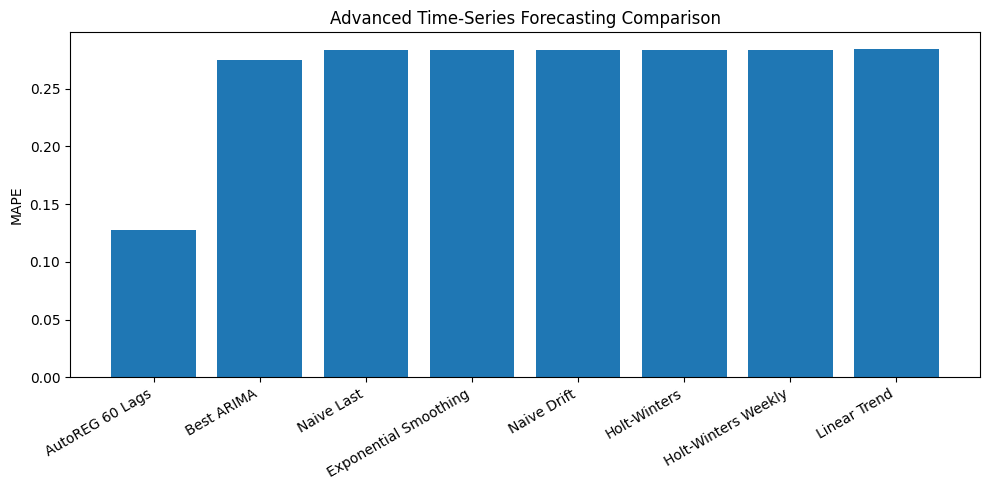

In [111]:
plt.figure(figsize=(10, 5))
plt.bar(forecast_results_df['model'], forecast_results_df['mape'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('MAPE')
plt.title('Advanced Time-Series Forecasting Comparison')
plt.tight_layout()
plt.show()


Plot the best model

In [112]:
best_forecast_model = forecast_results_df.sort_values('mape').iloc[0]['model']
best_forecast_model


'AutoREG 60 Lags'

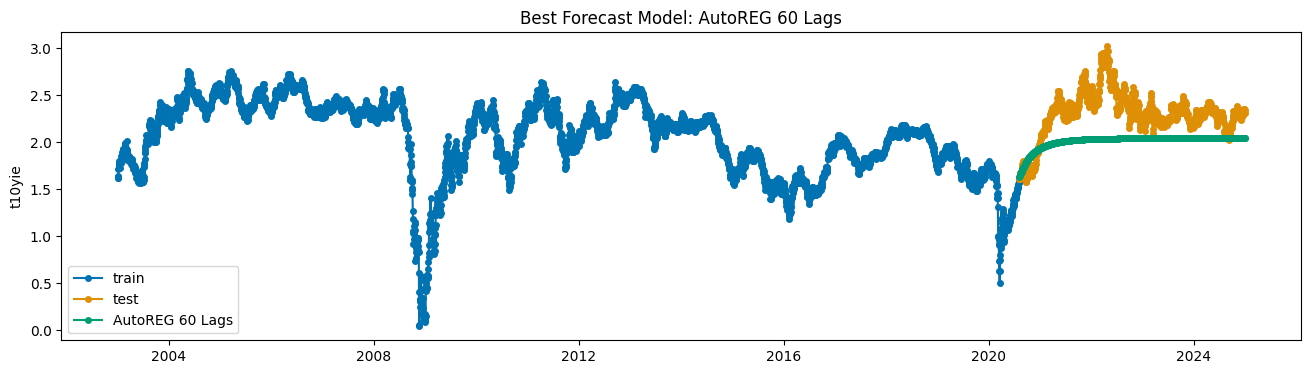

In [113]:

best_preds = autoreg_preds

plot_series(y_train_ts, y_test_ts, best_preds, labels=['train', 'test', best_forecast_model])
plt.title(f'Best Forecast Model: {best_forecast_model}')
plt.show()


## Tsfresh for time series model

In [114]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute


In [115]:
tsfresh_source_cols = [
    't10yie_change_1d',
    'dgs10_change_1d',
    'vix_change_1d',
    'wti_return_1d',
    'gas_return_1d'
]

window_size = 20

window_rows = []
window_dates = []

for i in range(window_size, len(df)):
    current_date = df.index[i]
    window = df.iloc[i-window_size:i]

    if window[tsfresh_source_cols].isna().any().any():
        continue

    for time_step, (_, row) in enumerate(window.iterrows()):
        for col in tsfresh_source_cols:
            window_rows.append({
                'id': current_date,
                'time': time_step,
                'kind': col,
                'value': row[col]
            })

    window_dates.append(current_date)

tsfresh_long = pd.DataFrame(window_rows)

tsfresh_long.head()


,id,time,kind,value
0,2003-01-31,0,t10yie_change_1d,-0.020000
1,2003-01-31,0,dgs10_change_1d,-0.020000
2,2003-01-31,0,vix_change_1d,-0.710000
3,2003-01-31,0,wti_return_1d,0.040350
4,2003-01-31,0,gas_return_1d,0.040568


In [116]:
X_tsfresh = extract_features(
    tsfresh_long,
    column_id='id',
    column_sort='time',
    column_kind='kind',
    column_value='value',
    default_fc_parameters=MinimalFCParameters(),
    n_jobs=0
)

impute(X_tsfresh)

print(X_tsfresh.shape)
X_tsfresh.head()


Feature Extraction: 100%|██████████| 28590/28590 [00:18<00:00, 1560.95it/s]


(5718, 50)


,dgs10_change_1d__sum_values,dgs10_change_1d__median,dgs10_change_1d__mean,dgs10_change_1d__length,dgs10_change_1d__standard_deviation,dgs10_change_1d__variance,dgs10_change_1d__root_mean_square,dgs10_change_1d__maximum,dgs10_change_1d__absolute_maximum,dgs10_change_1d__minimum,...,wti_return_1d__sum_values,wti_return_1d__median,wti_return_1d__mean,wti_return_1d__length,wti_return_1d__standard_deviation,wti_return_1d__variance,wti_return_1d__root_mean_square,wti_return_1d__maximum,wti_return_1d__absolute_maximum,wti_return_1d__minimum
2003-01-31,-0.07,-0.015,-0.0035,20.0,0.056945,0.003243,0.057053,0.19,0.19,-0.06,...,0.062557,0.008630,0.003128,20.0,0.027017,0.000730,0.027198,0.042074,0.072899,-0.072899
2003-02-03,-0.05,-0.005,-0.0025,20.0,0.056822,0.003229,0.056877,0.19,0.19,-0.06,...,0.014214,0.007741,0.000711,20.0,0.025710,0.000661,0.025720,0.042074,0.072899,-0.072899
2003-02-04,-0.08,-0.005,-0.0040,20.0,0.056071,0.003144,0.056214,0.19,0.19,-0.06,...,0.023384,0.007741,0.001169,20.0,0.025251,0.000638,0.025278,0.042074,0.072899,-0.072899
2003-02-05,-0.08,-0.005,-0.0040,20.0,0.056071,0.003144,0.056214,0.19,0.19,-0.06,...,0.080587,0.008630,0.004029,20.0,0.024357,0.000593,0.024688,0.042074,0.072899,-0.072899
2003-02-06,0.02,0.000,0.0010,20.0,0.057088,0.003259,0.057096,0.19,0.19,-0.06,...,0.106821,0.008930,0.005341,20.0,0.023874,0.000570,0.024464,0.042074,0.072899,-0.072899


In [117]:
target_tsfresh = df.loc[X_tsfresh.index, 'target_t10yie_change_5d']

tsfresh_model_df = X_tsfresh.copy()
tsfresh_model_df['target_t10yie_change_5d'] = target_tsfresh

tsfresh_model_df = tsfresh_model_df.dropna()

tsfresh_model_df.head()


,dgs10_change_1d__sum_values,dgs10_change_1d__median,dgs10_change_1d__mean,dgs10_change_1d__length,dgs10_change_1d__standard_deviation,dgs10_change_1d__variance,dgs10_change_1d__root_mean_square,dgs10_change_1d__maximum,dgs10_change_1d__absolute_maximum,dgs10_change_1d__minimum,...,wti_return_1d__median,wti_return_1d__mean,wti_return_1d__length,wti_return_1d__standard_deviation,wti_return_1d__variance,wti_return_1d__root_mean_square,wti_return_1d__maximum,wti_return_1d__absolute_maximum,wti_return_1d__minimum,target_t10yie_change_5d
2003-01-31,-0.07,-0.015,-0.0035,20.0,0.056945,0.003243,0.057053,0.19,0.19,-0.06,...,0.008630,0.003128,20.0,0.027017,0.000730,0.027198,0.042074,0.072899,-0.072899,0.08
2003-02-03,-0.05,-0.005,-0.0025,20.0,0.056822,0.003229,0.056877,0.19,0.19,-0.06,...,0.007741,0.000711,20.0,0.025710,0.000661,0.025720,0.042074,0.072899,-0.072899,0.12
2003-02-04,-0.08,-0.005,-0.0040,20.0,0.056071,0.003144,0.056214,0.19,0.19,-0.06,...,0.007741,0.001169,20.0,0.025251,0.000638,0.025278,0.042074,0.072899,-0.072899,0.09
2003-02-05,-0.08,-0.005,-0.0040,20.0,0.056071,0.003144,0.056214,0.19,0.19,-0.06,...,0.008630,0.004029,20.0,0.024357,0.000593,0.024688,0.042074,0.072899,-0.072899,-0.01
2003-02-06,0.02,0.000,0.0010,20.0,0.057088,0.003259,0.057096,0.19,0.19,-0.06,...,0.008930,0.005341,20.0,0.023874,0.000570,0.024464,0.042074,0.072899,-0.072899,0.00


some plottings of tsfresh

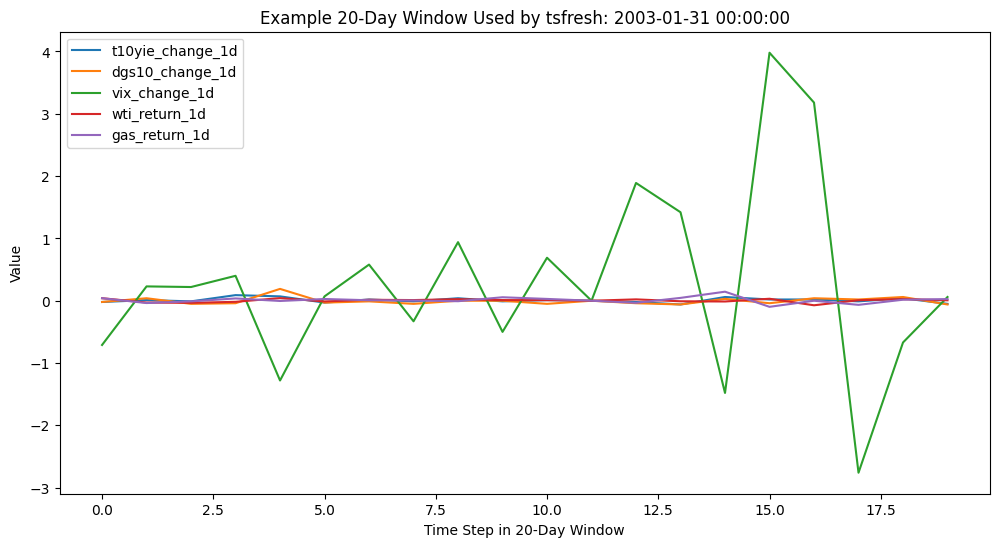

In [118]:
example_date = tsfresh_long['id'].iloc[0]

example_window = tsfresh_long[tsfresh_long['id'] == example_date]

plt.figure(figsize=(12, 6))

for kind in example_window['kind'].unique():
    temp = example_window[example_window['kind'] == kind]
    plt.plot(temp['time'], temp['value'], label=kind)

plt.xlabel('Time Step in 20-Day Window')
plt.ylabel('Value')
plt.title(f'Example 20-Day Window Used by tsfresh: {example_date}')
plt.legend()
plt.show()


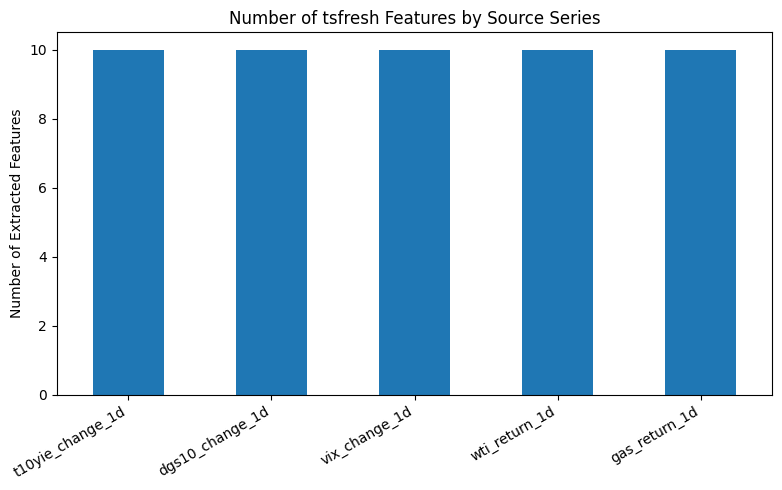

In [119]:
feature_counts = {}

for col in tsfresh_source_cols:
    feature_counts[col] = sum(X_tsfresh.columns.str.startswith(col))

feature_counts = pd.Series(feature_counts).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_counts.plot(kind='bar')
plt.ylabel('Number of Extracted Features')
plt.title('Number of tsfresh Features by Source Series')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [120]:
target_tsfresh = df.loc[X_tsfresh.index, 'target_t10yie_change_5d']

tsfresh_corr = X_tsfresh.corrwith(target_tsfresh).dropna()

top_tsfresh_corr = (
    tsfresh_corr
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

top_tsfresh_corr


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
wti_return_1d__median,0.058034
vix_change_1d__absolute_maximum,0.053211
dgs10_change_1d__mean,0.049583
dgs10_change_1d__sum_values,0.049583
vix_change_1d__maximum,0.049387
vix_change_1d__minimum,0.047006
vix_change_1d__standard_deviation,0.046361
vix_change_1d__root_mean_square,0.046208
dgs10_change_1d__minimum,0.044558
t10yie_change_1d__variance,0.043059


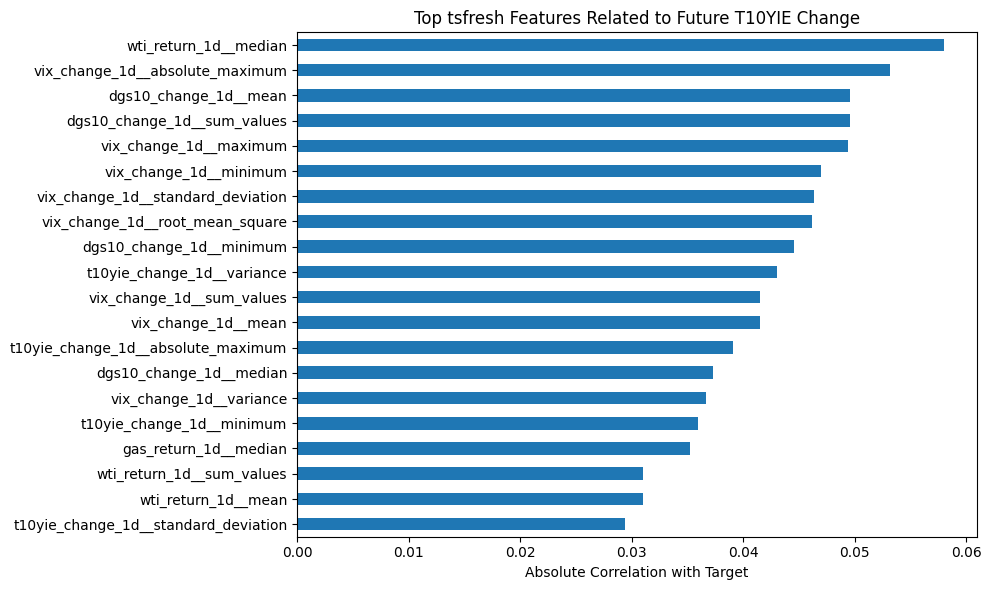

In [121]:
plt.figure(figsize=(10, 6))

top_tsfresh_corr.sort_values().plot(kind='barh')

plt.xlabel('Absolute Correlation with Target')
plt.title('Top tsfresh Features Related to Future T10YIE Change')
plt.tight_layout()
plt.show()


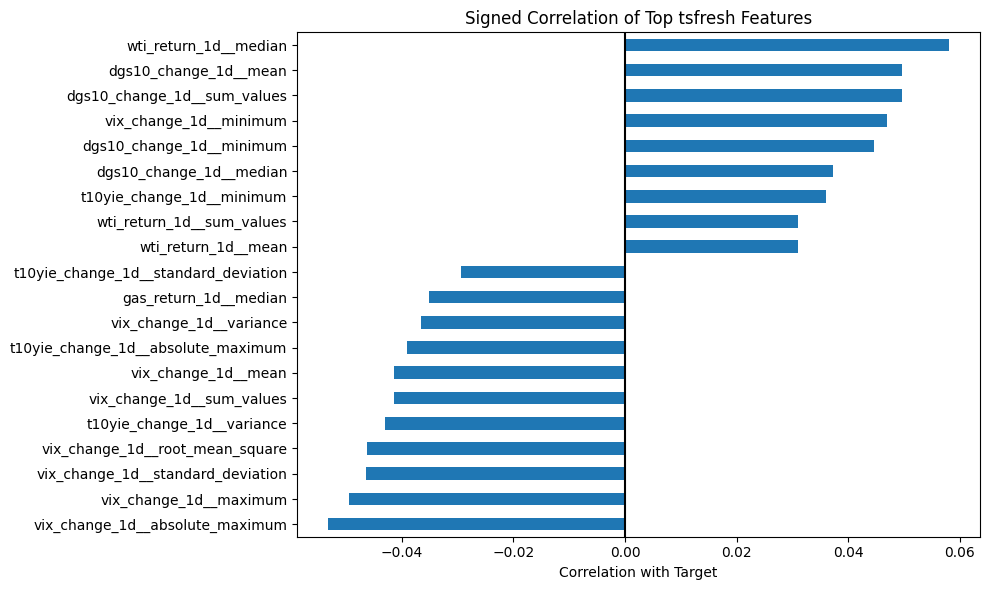

In [122]:
top_feature_names = top_tsfresh_corr.index

signed_top_corr = tsfresh_corr.loc[top_feature_names].sort_values()

plt.figure(figsize=(10, 6))
signed_top_corr.plot(kind='barh')
plt.axvline(0, color='black')
plt.xlabel('Correlation with Target')
plt.title('Signed Correlation of Top tsfresh Features')
plt.tight_layout()
plt.show()


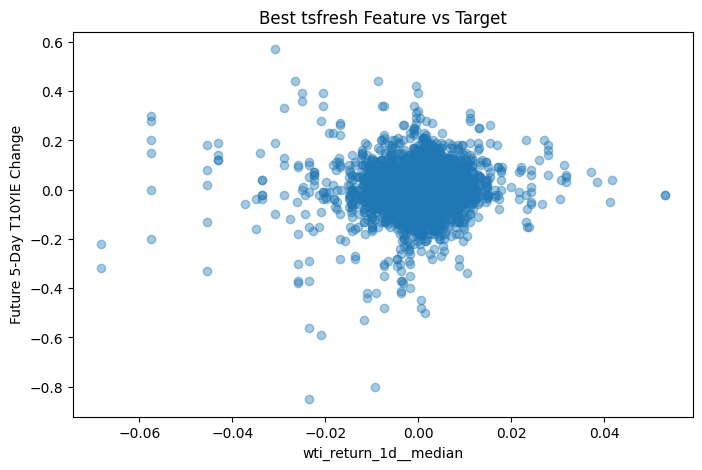

Best tsfresh feature: wti_return_1d__median


In [123]:
best_tsfresh_feature = top_tsfresh_corr.index[0]

plt.figure(figsize=(8, 5))
plt.scatter(
    X_tsfresh[best_tsfresh_feature],
    target_tsfresh,
    alpha=0.4
)

plt.xlabel(best_tsfresh_feature)
plt.ylabel('Future 5-Day T10YIE Change')
plt.title('Best tsfresh Feature vs Target')
plt.show()

print('Best tsfresh feature:', best_tsfresh_feature)


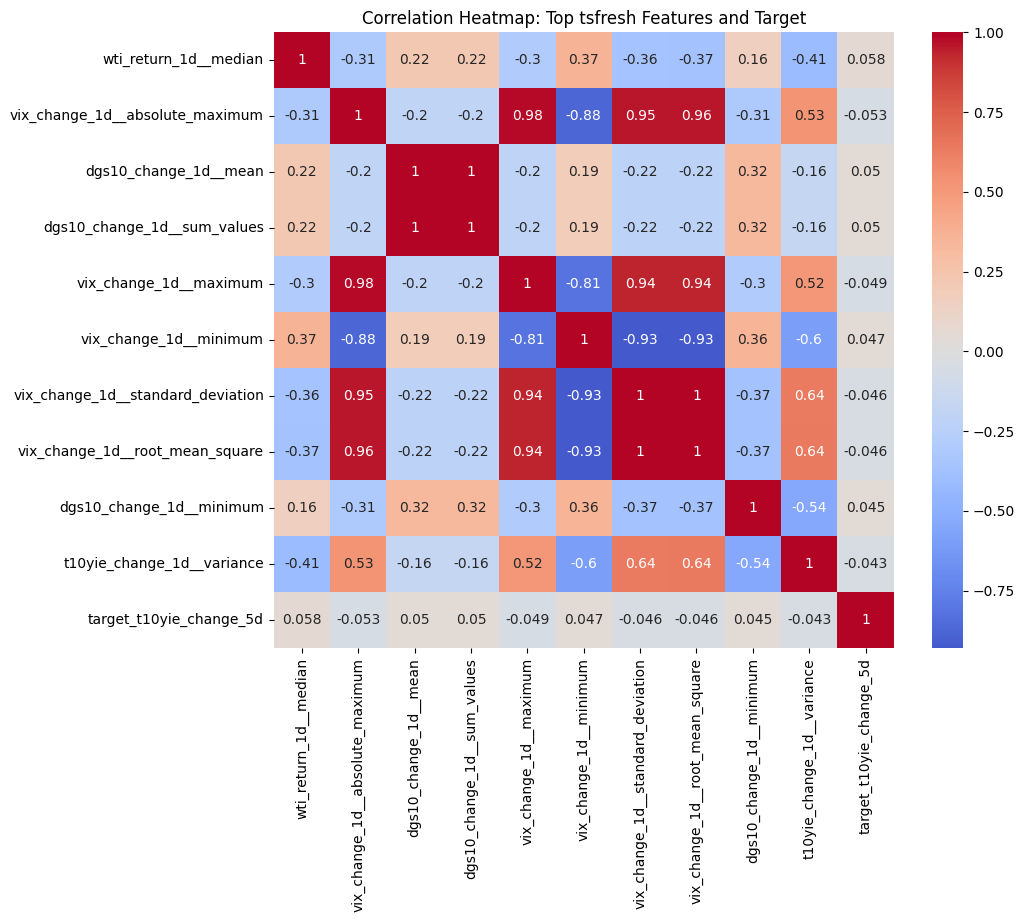

In [124]:
top_10_tsfresh_features = top_tsfresh_corr.head(10).index.tolist()

heatmap_df = X_tsfresh[top_10_tsfresh_features].copy()
heatmap_df['target_t10yie_change_5d'] = target_tsfresh

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_df.corr(),
    cmap='coolwarm',
    center=0,
    annot=True
)

plt.title('Correlation Heatmap: Top tsfresh Features and Target')
plt.show()


tsfresh extracts summary statistics from rolling 20-day windows, such as mean, standard deviation, maximum, minimum, and trend-like features. The plots show which automatically extracted recent time-series patterns have the strongest relationship with future 5-day changes in inflation expectations. This adds a higher-level time-series feature-engineering layer beyond manually created lags and rolling averages.